# 📦 Explainable Multi-Horizon Demand Forecasting with Probabilistic Inventory Optimization: A Unified Framework for Online Retail

**Dataset:** UCI Online Retail II  
**Katkılar:**
1. Densification ile literatür-uyumlu veri pipeline  
2. Multi-horizon tahmin (h=1, 7, 14 gün)  
3. Olasılıksal tahmin (Quantile Regression — P50, P75, P90)  
4. SHAP ile açıklanabilir tahminler  
5. Newsvendor stok optimizasyonu  
6. Gradio karar destek chatbot arayüzü

## 1. Environment Setup

In [1]:
!pip install -q prophet gradio shap xgboost lightgbm openpyxl
print("✅ All packages installed.")

✅ All packages installed.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta, date
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import lightgbm as lgb
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU as GRULayer, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import shap
import gradio as gr
from collections import OrderedDict

print(f"✅ All libraries imported. TF: {tf.__version__}")

✅ All libraries imported. TF: 2.20.0


In [3]:
import os, random
os.environ['TF_DETERMINISTIC_OPS'] = '1'
tf.keras.utils.set_random_seed(42)          # Python, NumPy ve TF seed'lerini birlikte sabitler
tf.config.experimental.enable_op_determinism()

In [4]:
# ─── 300 dpi Şekil İhracı ───
import os
FIGDIR = 'figures_300dpi'
os.makedirs(FIGDIR, exist_ok=True)
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['savefig.bbox'] = 'tight'

def save_fig(name):
    """Aktif figürü FIGDIR altına 300 dpi PNG olarak kaydeder."""
    path = os.path.join(FIGDIR, f'{name}.png')
    plt.gcf().savefig(path)
    print(f'  [kaydedildi] {path}')


## 2. Data Loading & Cleaning

In [5]:
# ─── Load Dataset ───
print("Loading Online Retail II...")
df1 = pd.read_excel('online_retail_II.xlsx', sheet_name='Year 2009-2010')
df2 = pd.read_excel('online_retail_II.xlsx', sheet_name='Year 2010-2011')
raw_df = pd.concat([df1, df2], ignore_index=True)
print(f"  Raw: {len(raw_df):,} records")

# ─── Cleaning (Literatür standardı) ───
# İptalleri temizle (Invoice 'C' ile başlayanlar)
df = raw_df[~raw_df['Invoice'].astype(str).str.startswith('C')].copy()
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]
df = df.dropna(subset=['StockCode', 'Description', 'Customer ID'])
df['StockCode'] = df['StockCode'].astype(str)
df = df[df['StockCode'].str.match(r'^\d+')]
df['Revenue'] = df['Quantity'] * df['Price']
df['date'] = df['InvoiceDate'].dt.normalize()
print(f"  Clean: {len(df):,} records")
print(f"  Range: {df['date'].min().date()} → {df['date'].max().date()}")

Loading Online Retail II...
  Raw: 1,067,371 records
  Clean: 802,632 records
  Range: 2009-12-01 → 2011-12-09


In [6]:
# ─── Top Products & Countries ───
prod_stats = df.groupby('StockCode').agg(
    total_revenue=('Revenue', 'sum'), total_qty=('Quantity', 'sum'),
    days_active=('date', 'nunique'),
    name=('Description', lambda x: x.mode().iloc[0])
)
prod_stats = prod_stats[prod_stats['days_active'] >= 200]
TOP_PRODUCTS = prod_stats.nlargest(10, 'total_revenue').index.tolist()
PRODUCT_NAMES = prod_stats.loc[TOP_PRODUCTS, 'name'].to_dict()

print("📦 Top 10 Products:")
for i, c in enumerate(TOP_PRODUCTS, 1):
    r = prod_stats.loc[c]
    print(f"  {i:2d}. [{c}] {r['name'][:45]:<45} £{r['total_revenue']:>10,.0f}")

TOP_COUNTRIES = df[df['StockCode'].isin(TOP_PRODUCTS)].groupby(
    'Country')['Revenue'].sum().nlargest(5).index.tolist()
print(f"\n🌍 Countries: {TOP_COUNTRIES}")

df = df[df['StockCode'].isin(TOP_PRODUCTS) & df['Country'].isin(TOP_COUNTRIES)]

📦 Top 10 Products:
   1. [22423] REGENCY CAKESTAND 3 TIER                      £   286,486
   2. [85123A] WHITE HANGING HEART T-LIGHT HOLDER            £   252,228
   3. [85099B] JUMBO BAG RED RETROSPOT                       £   170,617
   4. [84879] ASSORTED COLOUR BIRD ORNAMENT                 £   127,074
   5. [47566] PARTY BUNTING                                 £   103,880
   6. [22086] PAPER CHAIN KIT 50'S CHRISTMAS                £    79,594
   7. [79321] CHILLI LIGHTS                                 £    72,860
   8. [22386] JUMBO BAG PINK POLKADOT                       £    68,439
   9. [21137] BLACK RECORD COVER FRAME                      £    67,209
  10. [48138] DOORMAT UNION FLAG                            £    64,974

🌍 Countries: ['United Kingdom', 'Netherlands', 'EIRE', 'Germany', 'France']


## 3. 🔑 Densification (Sıfır Değerleriyle Yoğunlaştırma)

**Literatürdeki en kritik adım.** Veri seti sadece işlem yapılan günleri kaydeder.  
Bir SKU belirli bir gün satılmadıysa o gün için satır yoktur.  
Literatür standardı: Her SKU×Ülke kombinasyonu için **tüm takvim günlerini** oluştur ve satış olmayan günleri `Quantity = 0` ile doldur.

**Referans:** Ngartera et al. (2026) — %61.5 sıfır talep oranı raporlamıştır.

In [7]:
# ─── Daily Aggregation (Sadece işlem günleri) ───
daily_raw = df.groupby(['date', 'StockCode', 'Country']).agg(
    sales_quantity=('Quantity', 'sum'),
    total_revenue=('Revenue', 'sum'),
    unit_price=('Price', 'mean'),
    num_transactions=('Invoice', 'nunique'),
    num_customers=('Customer ID', 'nunique')
).reset_index()

print(f"📊 Daily records (before densification): {len(daily_raw):,}")

# ─── 🔑 DENSIFICATION — Literatürün altın standardı ───
# Her SKU×Ülke çifti için tam takvim günü paneli oluştur
all_dates = pd.date_range(daily_raw['date'].min(), daily_raw['date'].max(), freq='D')
all_combos = daily_raw.groupby(['StockCode', 'Country']).size().reset_index()[['StockCode', 'Country']]

# Cross join: tüm kombinasyonlar × tüm günler
panel_index = pd.MultiIndex.from_product(
    [all_combos.apply(lambda r: (r['StockCode'], r['Country']), axis=1).values, all_dates],
    names=['combo', 'date']
)

# Daha verimli yöntem:
panels = []
for _, row in all_combos.iterrows():
    combo_dates = pd.DataFrame({'date': all_dates})
    combo_dates['StockCode'] = row['StockCode']
    combo_dates['Country'] = row['Country']
    panels.append(combo_dates)

full_panel = pd.concat(panels, ignore_index=True)

# Mevcut satış verisiyle birleştir
daily_df = full_panel.merge(daily_raw, on=['date', 'StockCode', 'Country'], how='left')

# Satış olmayan günleri sıfırla doldur
daily_df['sales_quantity'] = daily_df['sales_quantity'].fillna(0)
daily_df['total_revenue'] = daily_df['total_revenue'].fillna(0)
daily_df['num_transactions'] = daily_df['num_transactions'].fillna(0)
daily_df['num_customers'] = daily_df['num_customers'].fillna(0)

# Birim fiyat: son bilinen fiyat ile doldur (forward fill)
daily_df = daily_df.sort_values(['StockCode', 'Country', 'date'])
daily_df['unit_price'] = daily_df.groupby(['StockCode', 'Country'])['unit_price'].ffill().bfill()

daily_df['product_name'] = daily_df['StockCode'].map(PRODUCT_NAMES)
daily_df['store_name'] = daily_df['Country']

# İstatistikler
zero_share = (daily_df['sales_quantity'] == 0).mean() * 100
print(f"📊 Daily records (after densification): {len(daily_df):,}")
print(f"📊 Zero-demand share: {zero_share:.1f}% (Ngartera raporladığı: 61.5%)")
print(f"📊 Non-zero days: {(daily_df['sales_quantity'] > 0).sum():,}")
print(f"📊 Zero days: {(daily_df['sales_quantity'] == 0).sum():,}")
print(f"📊 SKU×Country combinations: {len(all_combos)}")

📊 Daily records (before densification): 5,636
📊 Daily records (after densification): 33,255
📊 Zero-demand share: 83.1% (Ngartera raporladığı: 61.5%)
📊 Non-zero days: 5,636
📊 Zero days: 27,619
📊 SKU×Country combinations: 45


## 4. Feature Engineering (Literatür Standardı)

In [8]:
# ─── Feature Engineering ───
UK_HOLIDAYS = {
    date(2009,12,25), date(2009,12,26), date(2009,12,28),
    date(2010,1,1), date(2010,4,2), date(2010,4,5), date(2010,5,3),
    date(2010,5,31), date(2010,8,30), date(2010,12,25), date(2010,12,26), date(2010,12,27),
    date(2011,1,1), date(2011,1,3), date(2011,4,22), date(2011,4,25),
    date(2011,4,29), date(2011,5,2), date(2011,5,30), date(2011,8,29),
    date(2011,12,25), date(2011,12,26), date(2011,12,27),
}

merged_df = daily_df.sort_values(['StockCode', 'Country', 'date']).reset_index(drop=True)
grp = merged_df.groupby(['StockCode', 'Country'])

# ── Calendar Features ──
merged_df['day_of_week'] = pd.to_datetime(merged_df['date']).dt.dayofweek
merged_df['month'] = pd.to_datetime(merged_df['date']).dt.month
merged_df['day_of_month'] = pd.to_datetime(merged_df['date']).dt.day
merged_df['week_of_year'] = pd.to_datetime(merged_df['date']).dt.isocalendar().week.astype(int)
merged_df['is_weekend'] = (merged_df['day_of_week'] >= 5).astype(int)
merged_df['is_holiday'] = merged_df['date'].apply(lambda x: int(x.date() in UK_HOLIDAYS))

# Fourier features
merged_df['sin_dow'] = np.sin(2 * np.pi * merged_df['day_of_week'] / 7)
merged_df['cos_dow'] = np.cos(2 * np.pi * merged_df['day_of_week'] / 7)
merged_df['sin_month'] = np.sin(2 * np.pi * merged_df['month'] / 12)
merged_df['cos_month'] = np.cos(2 * np.pi * merged_df['month'] / 12)

# ── Lag Features (artık densification ile doğru!) ──
for lag in [1, 7, 14, 28]:
    merged_df[f'sales_lag_{lag}'] = grp['sales_quantity'].shift(lag)

# ── Rolling Statistics (shift(1) — data leakage yok) ──
shifted = grp['sales_quantity'].shift(1)
merged_df['rolling_mean_7'] = shifted.rolling(7, min_periods=3).mean().values
merged_df['rolling_std_7'] = shifted.rolling(7, min_periods=3).std().values
merged_df['rolling_mean_28'] = shifted.rolling(28, min_periods=7).mean().values
merged_df['rolling_std_28'] = shifted.rolling(28, min_periods=7).std().values

# EWM
merged_df['ewm_7'] = shifted.ewm(span=7, min_periods=3).mean().values

# Trend
merged_df['trend_7_28'] = (merged_df['rolling_mean_7'] - merged_df['rolling_mean_28']).fillna(0)

# Price features
merged_df['price_change'] = grp['unit_price'].pct_change().fillna(0).clip(-1, 1).values

# Encode
le_product = LabelEncoder()
le_country = LabelEncoder()
merged_df['product_encoded'] = le_product.fit_transform(merged_df['StockCode'])
merged_df['country_encoded'] = le_country.fit_transform(merged_df['Country'])

# Clean NaN (ilk 28 gün lag nedeniyle NaN olacak)
merged_df = merged_df.dropna().reset_index(drop=True)

# Outlier cap
q995 = merged_df['sales_quantity'].quantile(0.995)
merged_df = merged_df[merged_df['sales_quantity'] <= q995].reset_index(drop=True)

FEATURE_COLS = [
    'unit_price', 'num_transactions', 'num_customers',
    'day_of_week', 'month', 'day_of_month', 'week_of_year',
    'is_weekend', 'is_holiday',
    'sin_dow', 'cos_dow', 'sin_month', 'cos_month',
    'sales_lag_1', 'sales_lag_7', 'sales_lag_14', 'sales_lag_28',
    'rolling_mean_7', 'rolling_std_7', 'rolling_mean_28', 'rolling_std_28',
    'ewm_7', 'trend_7_28',
    'price_change', 'product_encoded', 'country_encoded'
]
TARGET_COL = 'sales_quantity'

print(f"✅ {len(merged_df):,} records, {len(FEATURE_COLS)} features")
print(f"   Zero-demand ratio in final data: {(merged_df['sales_quantity']==0).mean()*100:.1f}%")

✅ 31,835 records, 26 features
   Zero-demand ratio in final data: 83.2%


  [kaydedildi] figures_300dpi/fig03_correlation.png


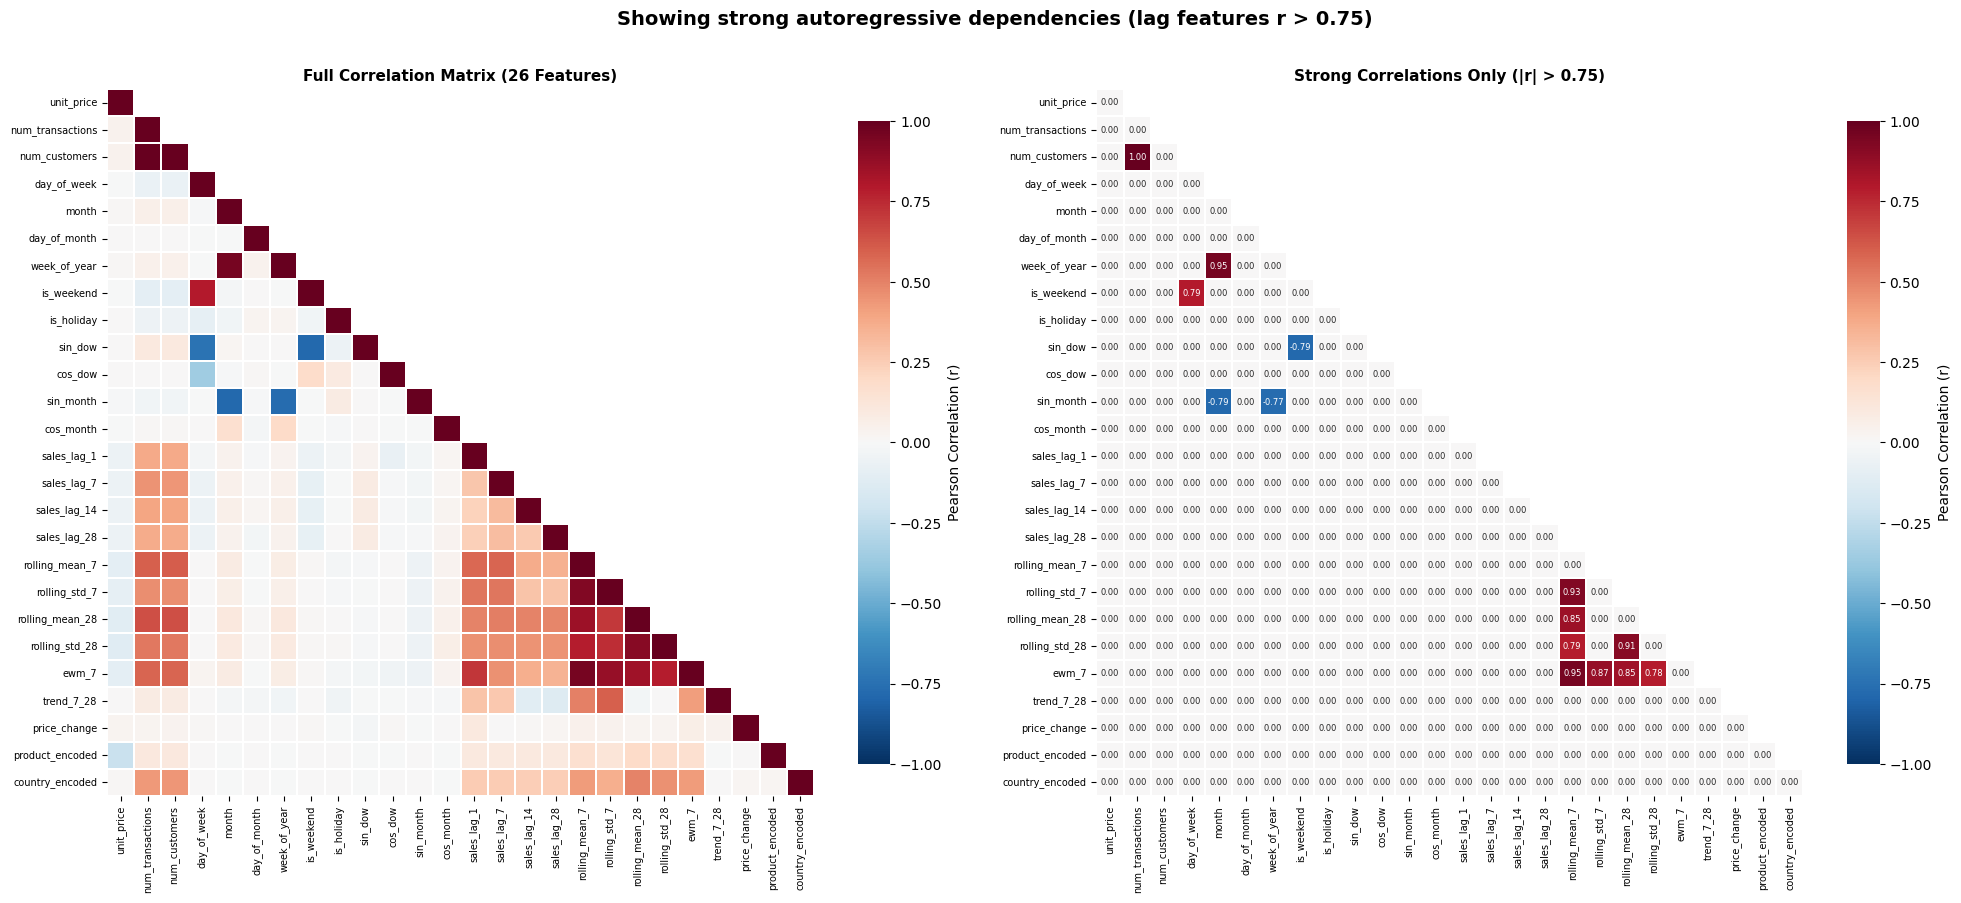


📊 Strong Autoregressive Dependencies (|r| > 0.75):
───────────────────────────────────────────────────────
  num_transactions          ↔ num_customers             r = +0.9982
  month                     ↔ week_of_year              r = +0.9548
  rolling_mean_7            ↔ ewm_7                     r = +0.9540
  rolling_mean_7            ↔ rolling_std_7             r = +0.9253
  rolling_mean_28           ↔ rolling_std_28            r = +0.9094
  rolling_std_7             ↔ ewm_7                     r = +0.8722
  rolling_mean_7            ↔ rolling_mean_28           r = +0.8516
  rolling_mean_28           ↔ ewm_7                     r = +0.8476
  day_of_week               ↔ is_weekend                r = +0.7902
  month                     ↔ sin_month                 r = -0.7885
  rolling_mean_7            ↔ rolling_std_28            r = +0.7875
  is_weekend                ↔ sin_dow                   r = -0.7852
  rolling_std_28            ↔ ewm_7                     r = +0.7848
  week_o

In [9]:
# ─── Figure 5.2: Correlation Heatmap of 26 Engineered Features ───
corr_matrix = merged_df[FEATURE_COLS].corr()

# Güçlü otoregresif bağımlılıkları vurgulamak için maske (|r| > 0.75)
strong_mask = corr_matrix.abs() > 0.75
# Üst üçgeni gizlemek için maske
triangle_mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

fig, axes = plt.subplots(1, 2, figsize=(20, 9))
fig.suptitle('Showing strong autoregressive dependencies (lag features r > 0.75)',
             fontsize=14, fontweight='bold')

# Sol: Tam korelasyon matrisi
sns.heatmap(corr_matrix, mask=triangle_mask, annot=False,
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.3, linecolor='white',
            cbar_kws={'label': 'Pearson Correlation (r)', 'shrink': 0.8},
            ax=axes[0])
axes[0].set_title('Full Correlation Matrix (26 Features)', fontsize=11, fontweight='bold')
axes[0].tick_params(axis='x', rotation=90, labelsize=7)
axes[0].tick_params(axis='y', rotation=0, labelsize=7)

# Sağ: Sadece güçlü korelasyonları göster (|r| > 0.75)
corr_strong = corr_matrix.where(strong_mask, other=0)
# Diagonal'i sıfırla (kendi kendisiyle korelasyon göstermesin)
np.fill_diagonal(corr_strong.values, 0)

sns.heatmap(corr_strong, mask=triangle_mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.3, linecolor='white',
            annot_kws={'size': 6},
            cbar_kws={'label': 'Pearson Correlation (r)', 'shrink': 0.8},
            ax=axes[1])
axes[1].set_title('Strong Correlations Only (|r| > 0.75)', fontsize=11, fontweight='bold')
axes[1].tick_params(axis='x', rotation=90, labelsize=7)
axes[1].tick_params(axis='y', rotation=0, labelsize=7)

plt.tight_layout()
save_fig('fig03_correlation')
plt.show()

# Güçlü korelasyonları listele
print("\n📊 Strong Autoregressive Dependencies (|r| > 0.75):")
print("─" * 55)
pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.75:
            pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], r))
pairs.sort(key=lambda x: abs(x[2]), reverse=True)
for f1, f2, r in pairs:
    print(f"  {f1:<25} ↔ {f2:<25} r = {r:+.4f}")


## 5. EDA (Densification Sonrası)

  DATASET OVERVIEW (Post-Densification)
  Records: 31,835 | Features: 26
  Date: 2009-12-29 → 2011-12-09
  Products: 10 | Countries: 5
  Zero-demand ratio: 83.2%
  Mean demand: 9.45
  Median demand: 0.0
  Std demand: 35.23
  Skewness: 5.33
  [kaydedildi] figures_300dpi/fig02_eda_dashboard.png


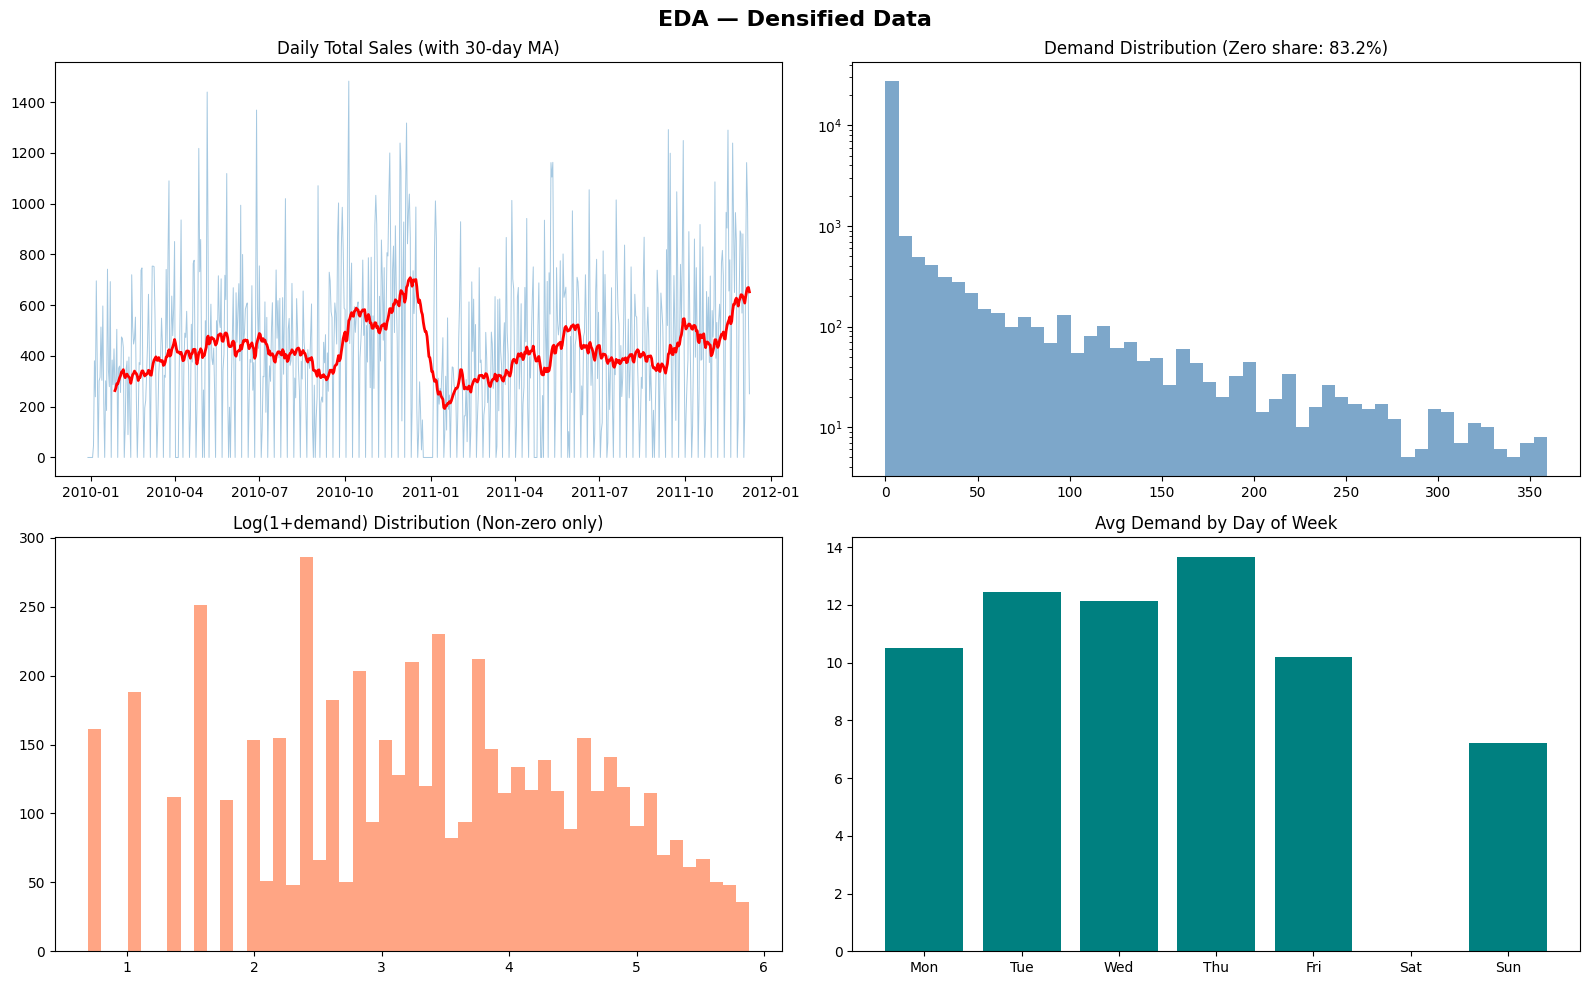

In [10]:
# ─── EDA ───
print("=" * 70)
print("  DATASET OVERVIEW (Post-Densification)")
print("=" * 70)
print(f"  Records: {len(merged_df):,} | Features: {len(FEATURE_COLS)}")
print(f"  Date: {merged_df['date'].min().date()} → {merged_df['date'].max().date()}")
print(f"  Products: {merged_df['StockCode'].nunique()} | Countries: {merged_df['Country'].nunique()}")
print(f"  Zero-demand ratio: {(merged_df['sales_quantity']==0).mean()*100:.1f}%")
print(f"  Mean demand: {merged_df['sales_quantity'].mean():.2f}")
print(f"  Median demand: {merged_df['sales_quantity'].median():.1f}")
print(f"  Std demand: {merged_df['sales_quantity'].std():.2f}")
print(f"  Skewness: {merged_df['sales_quantity'].skew():.2f}")

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('EDA — Densified Data', fontsize=16, fontweight='bold')

# Daily trend
daily_total = merged_df.groupby('date')['sales_quantity'].sum()
axes[0,0].plot(daily_total.index, daily_total.values, alpha=0.4, linewidth=0.7)
axes[0,0].plot(daily_total.index, daily_total.rolling(30).mean(), color='red', linewidth=2)
axes[0,0].set_title('Daily Total Sales (with 30-day MA)')

# Distribution
axes[0,1].hist(merged_df['sales_quantity'], bins=50, alpha=0.7, color='steelblue')
axes[0,1].set_title(f'Demand Distribution (Zero share: {(merged_df["sales_quantity"]==0).mean()*100:.1f}%)')
axes[0,1].set_yscale('log')

# Log-transformed (nonzero)
nonzero = merged_df[merged_df['sales_quantity'] > 0]['sales_quantity']
axes[1,0].hist(np.log1p(nonzero), bins=50, alpha=0.7, color='coral')
axes[1,0].set_title('Log(1+demand) Distribution (Non-zero only)')

# By day of week
dow_avg = merged_df.groupby('day_of_week')['sales_quantity'].mean()
axes[1,1].bar(dow_avg.index, dow_avg.values, color='teal')
axes[1,1].set_title('Avg Demand by Day of Week')
axes[1,1].set_xticks(range(7))
axes[1,1].set_xticklabels(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])

plt.tight_layout(); save_fig('fig02_eda_dashboard')
plt.show()

## 6. Data Preparation
### Log1p transform + Chronological split + Multi-horizon targets

In [11]:
# ─── Demo Product: En çok satılan SKU (UK) ───
demo_product = merged_df[merged_df['Country']=='United Kingdom'].groupby(
    'StockCode')['sales_quantity'].sum().idxmax()
demo_country = 'United Kingdom'
demo_mask = (merged_df['StockCode'] == demo_product) & (merged_df['Country'] == demo_country)
demo_data = merged_df[demo_mask].sort_values('date').reset_index(drop=True)

print(f"📌 Demo: [{demo_product}] {PRODUCT_NAMES.get(demo_product, 'N/A')}")
print(f"   Records: {len(demo_data)} | Mean: {demo_data['sales_quantity'].mean():.1f}")
print(f"   Zero-demand days: {(demo_data['sales_quantity']==0).mean()*100:.1f}%")

# ─── Log transform ───
demo_data = demo_data.copy()
demo_data['log_sales'] = np.log1p(demo_data['sales_quantity'])

# ─── Chronological split: 80% train, 20% test ───
split = int(len(demo_data) * 0.8)
train_data = demo_data.iloc[:split]
test_data = demo_data.iloc[split:]

print(f"   Train: {len(train_data)} | Test: {len(test_data)}")
print(f"   Train period: {train_data['date'].min().date()} → {train_data['date'].max().date()}")
print(f"   Test period: {test_data['date'].min().date()} → {test_data['date'].max().date()}")

X_train = train_data[FEATURE_COLS].values
y_train = train_data['log_sales'].values
X_test = test_data[FEATURE_COLS].values
y_test = test_data['log_sales'].values
y_actual = test_data['sales_quantity'].values

# Scale features
scaler_X = RobustScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

📌 Demo: [85123A] WHITE HANGING HEART T-LIGHT HOLDER
   Records: 676 | Mean: 83.5
   Zero-demand days: 19.1%
   Train: 540 | Test: 136
   Train period: 2009-12-29 → 2011-07-21
   Test period: 2011-07-22 → 2011-12-09


## 7. Model Training & Evaluation (h=1 Horizon)

In [12]:
# ─── Evaluation Helpers ───
def calc_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mask = y_true > 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100 if mask.sum() > 0 else 999
    # SMAPE (sıfır-güvenli)
    denom = (np.abs(y_true) + np.abs(y_pred))
    smape = np.mean(2 * np.abs(y_true - y_pred) / np.maximum(denom, 1)) * 100
    return {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MAPE': mape, 'SMAPE': smape}

all_results = OrderedDict()
predictions = {}

In [13]:
# ─── LightGBM (Ana model — SHAP ve Quantile için) ───
lgb_model = lgb.LGBMRegressor(
    n_estimators=500, max_depth=6, learning_rate=0.03,
    num_leaves=31, min_child_samples=10,
    colsample_bytree=0.7, subsample=0.8, subsample_freq=3,
    reg_alpha=0.1, reg_lambda=1.0,
    random_state=42, verbosity=-1
)
lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(0)]
)
y_pred_lgb = np.maximum(np.expm1(lgb_model.predict(X_test)), 0)
all_results['LightGBM'] = calc_metrics(y_actual, y_pred_lgb)
predictions['LightGBM'] = y_pred_lgb
print(f"✅ LightGBM — R²: {all_results['LightGBM']['R2']:.4f}, MAE: {all_results['LightGBM']['MAE']:.2f}")

✅ LightGBM — R²: 0.6136, MAE: 20.27


In [14]:
# ─── XGBoost ───
xgb_model = xgb.XGBRegressor(
    n_estimators=500, max_depth=6, learning_rate=0.03,
    subsample=0.8, colsample_bytree=0.7,
    min_child_weight=5, reg_alpha=0.1, reg_lambda=1.0,
    random_state=42, verbosity=0, early_stopping_rounds=30
)
xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
y_pred_xgb = np.maximum(np.expm1(xgb_model.predict(X_test)), 0)
all_results['XGBoost'] = calc_metrics(y_actual, y_pred_xgb)
predictions['XGBoost'] = y_pred_xgb
print(f"✅ XGBoost — R²: {all_results['XGBoost']['R2']:.4f}, MAE: {all_results['XGBoost']['MAE']:.2f}")

✅ XGBoost — R²: 0.6109, MAE: 20.41


In [15]:
# ─── Random Forest ───
rf_model = RandomForestRegressor(
    n_estimators=300, max_depth=12, min_samples_split=5,
    min_samples_leaf=3, max_features=0.6, random_state=42, n_jobs=-1
)
rf_model.fit(X_train, y_train)
y_pred_rf = np.maximum(np.expm1(rf_model.predict(X_test)), 0)
all_results['Random Forest'] = calc_metrics(y_actual, y_pred_rf)
predictions['Random Forest'] = y_pred_rf
print(f"✅ RF — R²: {all_results['Random Forest']['R2']:.4f}, MAE: {all_results['Random Forest']['MAE']:.2f}")

✅ RF — R²: 0.6269, MAE: 19.61


In [16]:
# ─── LSTM ───
WINDOW = 14
def make_sequences(X, y, w):
    Xs, ys = [], []
    for i in range(w, len(X)):
        Xs.append(X[i-w:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

from sklearn.preprocessing import MinMaxScaler
scaler_y = MinMaxScaler()
X_all_scaled = scaler_X.transform(demo_data[FEATURE_COLS].values)
y_all_log = demo_data['log_sales'].values.reshape(-1,1)
y_all_scaled = scaler_y.fit_transform(y_all_log)

X_seq, y_seq = make_sequences(X_all_scaled, y_all_scaled, WINDOW)
split_seq = split - WINDOW
X_tr_seq, X_te_seq = X_seq[:split_seq], X_seq[split_seq:]
y_tr_seq, y_te_seq = y_seq[:split_seq], y_seq[split_seq:]

lstm_model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(WINDOW, len(FEATURE_COLS))),
    BatchNormalization(), Dropout(0.2),
    LSTM(32, return_sequences=False),
    BatchNormalization(), Dropout(0.2),
    Dense(16, activation='relu'), Dense(1)
])
lstm_model.compile(optimizer=tf.keras.optimizers.Adam(0.0005), loss='huber', metrics=['mae'])
lstm_model.fit(X_tr_seq, y_tr_seq, validation_split=0.2, epochs=100, batch_size=16,
    callbacks=[EarlyStopping('val_loss', patience=15, restore_best_weights=True),
              ReduceLROnPlateau('val_loss', factor=0.5, patience=7, min_lr=1e-6)], verbose=0)

y_pred_lstm_scaled = lstm_model.predict(X_te_seq, verbose=0)
y_pred_lstm_log = scaler_y.inverse_transform(y_pred_lstm_scaled).flatten()
y_pred_lstm = np.maximum(np.expm1(y_pred_lstm_log), 0)
y_actual_lstm = y_actual[WINDOW:] if len(y_actual) > len(y_pred_lstm) else y_actual[:len(y_pred_lstm)]
# Align lengths
min_len = min(len(y_actual_lstm), len(y_pred_lstm))
y_actual_lstm = y_actual_lstm[:min_len]
y_pred_lstm = y_pred_lstm[:min_len]

all_results['LSTM'] = calc_metrics(y_actual_lstm, y_pred_lstm)
print(f"✅ LSTM — R²: {all_results['LSTM']['R2']:.4f}, MAE: {all_results['LSTM']['MAE']:.2f}")

✅ LSTM — R²: -1.4908, MAE: 57.96


In [17]:
# ─── GRU ───
gru_model = Sequential([
    GRULayer(48, return_sequences=True, input_shape=(WINDOW, len(FEATURE_COLS))),
    BatchNormalization(), Dropout(0.2),
    GRULayer(24, return_sequences=False),
    BatchNormalization(), Dropout(0.2),
    Dense(16, activation='relu'), Dense(1)
])
gru_model.compile(optimizer=tf.keras.optimizers.Adam(0.0005), loss='huber', metrics=['mae'])
gru_model.fit(X_tr_seq, y_tr_seq, validation_split=0.2, epochs=100, batch_size=16,
    callbacks=[EarlyStopping('val_loss', patience=15, restore_best_weights=True),
              ReduceLROnPlateau('val_loss', factor=0.5, patience=7, min_lr=1e-6)], verbose=0)

y_pred_gru_scaled = gru_model.predict(X_te_seq, verbose=0)
y_pred_gru_log = scaler_y.inverse_transform(y_pred_gru_scaled).flatten()
y_pred_gru = np.maximum(np.expm1(y_pred_gru_log), 0)[:min_len]

all_results['GRU'] = calc_metrics(y_actual_lstm, y_pred_gru)
print(f"✅ GRU — R²: {all_results['GRU']['R2']:.4f}, MAE: {all_results['GRU']['MAE']:.2f}")

✅ GRU — R²: -1.2126, MAE: 60.36


In [18]:
# ─── Ensemble (R²-weighted) ───
# Flat modeller (aynı uzunlukta)
ens_preds = {'LightGBM': y_pred_lgb, 'XGBoost': y_pred_xgb, 'Random Forest': y_pred_rf}
good = {k: v for k, v in ens_preds.items() if all_results[k]['R2'] > 0}
if len(good) >= 2:
    weights = {k: all_results[k]['R2'] for k in good}
    tw = sum(weights.values())
    y_pred_ens = sum(weights[k]/tw * v for k, v in good.items())
else:
    y_pred_ens = np.mean(list(ens_preds.values()), axis=0)

all_results['Ensemble'] = calc_metrics(y_actual, y_pred_ens)
predictions['Ensemble'] = y_pred_ens
print(f"✅ Ensemble — R²: {all_results['Ensemble']['R2']:.4f}, MAE: {all_results['Ensemble']['MAE']:.2f}")

✅ Ensemble — R²: 0.6200, MAE: 19.92


  MODEL COMPARISON (Densified Data — h=1)
Model                     MAE     RMSE       R²    MAPE%   SMAPE%
────────────────────────────────────────────────────────────
Random Forest           19.61    37.20   0.6269     42.7     28.4 ⭐
Ensemble                19.92    37.54   0.6200     43.3     30.6
LightGBM                20.27    37.86   0.6136     43.6     32.3
XGBoost                 20.41    37.99   0.6109     44.5     31.8
GRU                     60.36    90.59  -1.2126    163.0    111.0
LSTM                    57.96    96.11  -1.4908    238.0    120.8
  [kaydedildi] figures_300dpi/fig05_actual_vs_pred.png


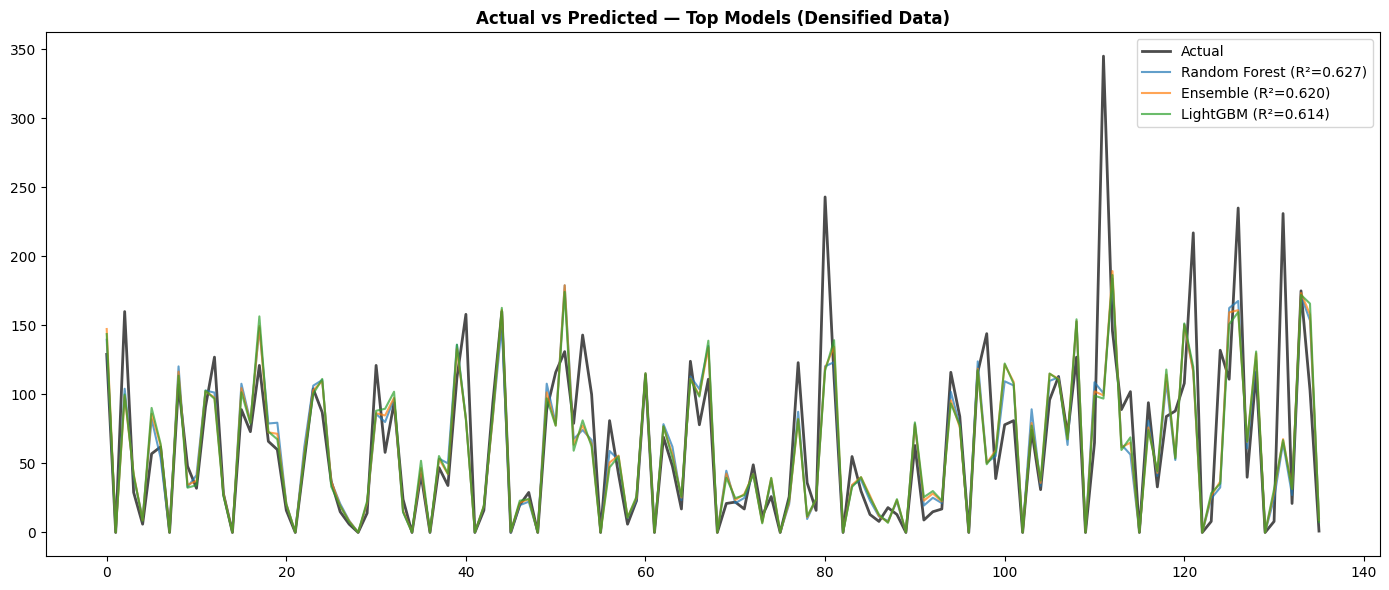

In [19]:
# ─── Model Comparison Table ───
comparison_df = pd.DataFrame(all_results).T.round(4).sort_values('R2', ascending=False)
print("=" * 75)
print("  MODEL COMPARISON (Densified Data — h=1)")
print("=" * 75)
print(f"{'Model':<20} {'MAE':>8} {'RMSE':>8} {'R²':>8} {'MAPE%':>8} {'SMAPE%':>8}")
print("─" * 60)
for n, r in comparison_df.iterrows():
    m = ' ⭐' if n == comparison_df.index[0] else ''
    print(f"{n:<20} {r['MAE']:>8.2f} {r['RMSE']:>8.2f} {r['R2']:>8.4f} {r['MAPE']:>8.1f} {r['SMAPE']:>8.1f}{m}")

# Visualization
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(y_actual, label='Actual', color='black', linewidth=2, alpha=0.7)
for n in comparison_df.index[:3]:
    if n in predictions:
        ax.plot(predictions[n], label=f"{n} (R²={comparison_df.loc[n,'R2']:.3f})", alpha=0.7)
ax.set_title('Actual vs Predicted — Top Models (Densified Data)', fontweight='bold')
ax.legend(); plt.tight_layout(); save_fig('fig05_actual_vs_pred')
plt.show()

  [kaydedildi] figures_300dpi/fig04_model_comparison.png


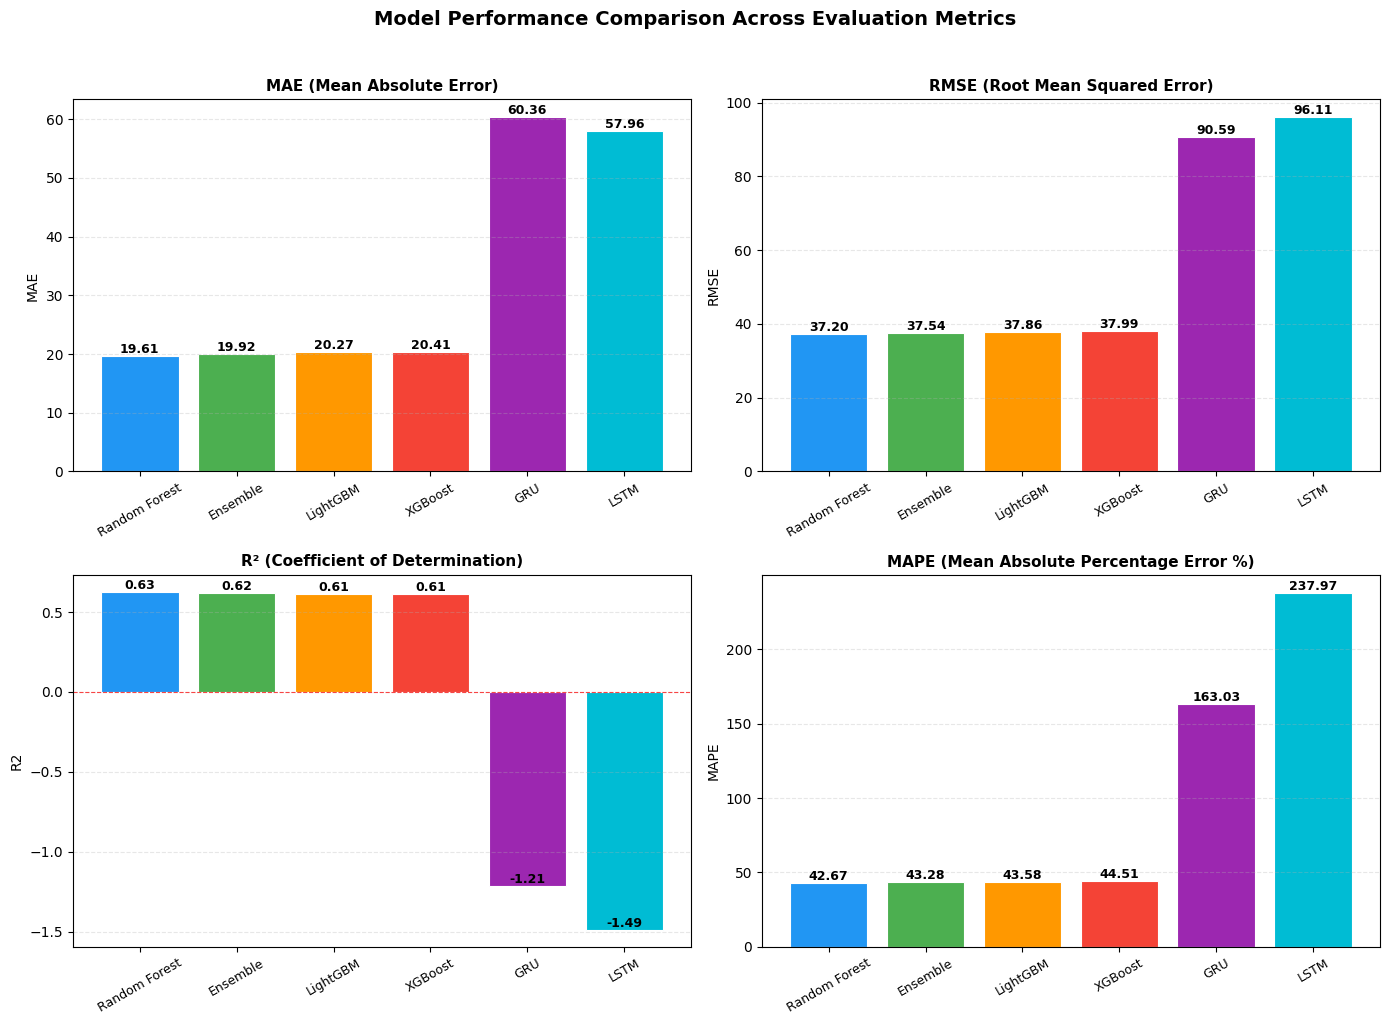

In [20]:
# ─── Figure 5.4: Model Performance Comparison Bar Charts ───
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Model Performance Comparison Across Evaluation Metrics',
             fontsize=14, fontweight='bold', y=1.02)

metrics = ['MAE', 'RMSE', 'R2', 'MAPE']
titles  = ['MAE (Mean Absolute Error)',
           'RMSE (Root Mean Squared Error)',
           'R² (Coefficient of Determination)',
           'MAPE (Mean Absolute Percentage Error %)']
colors  = ['#2196F3', '#4CAF50', '#FF9800', '#F44336', '#9C27B0', '#00BCD4']

for idx, (metric, title) in enumerate(zip(metrics, titles)):
    ax = axes[idx // 2, idx % 2]
    values = comparison_df[metric]
    bars = ax.bar(values.index, values.values,
                  color=colors[:len(values)], edgecolor='white', linewidth=0.8)

    # Her çubuğun üstüne değer yaz
    for bar, val in zip(bars, values.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                f'{val:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel(metric, fontsize=10)
    ax.tick_params(axis='x', rotation=30, labelsize=9)
    ax.grid(axis='y', alpha=0.3, linestyle='--')

    # R² için y ekseni sınırlarını ayarla (negatif değerler olabilir)
    if metric == 'R2':
        ax.axhline(y=0, color='red', linestyle='--', linewidth=0.8, alpha=0.7)

plt.tight_layout()
save_fig('fig04_model_comparison')
plt.show()


### 7.1. Diebold-Mariano Testi
Ağaç-tabanlı modeller arasındaki performans farkının istatistiksel anlamlılığı.

In [21]:
# ─── Diebold-Mariano Testi  ───
# H0: iki modelin beklenen kaybı eşit. h=1, Harvey-Leybourne-Newbold düzeltmesi.
# Beklenen sonuç: tüm ağaç-tabanlı çiftlerde p > 0.05 → §4.3'teki
# "Diebold-Mariano test would be needed" cümlesi gerçek sonuçla güncellenecek.
from scipy import stats as _st

def diebold_mariano(e1, e2, loss='abs', h_horizon=1):
    """DM testi (HLN küçük-örneklem düzeltmeli). e1,e2: hata dizileri."""
    e1, e2 = np.asarray(e1, float), np.asarray(e2, float)
    d = (np.abs(e1) - np.abs(e2)) if loss == 'abs' else (e1**2 - e2**2)
    T = len(d); dbar = d.mean()
    var_d = np.mean((d - dbar) ** 2)
    for lag in range(1, h_horizon):
        var_d += 2 * np.mean((d[lag:] - dbar) * (d[:-lag] - dbar))
    dm = dbar / np.sqrt(var_d / T)
    hln = np.sqrt((T + 1 - 2*h_horizon + h_horizon*(h_horizon-1)/T) / T)
    dm *= hln
    p = 2 * (1 - _st.t.cdf(abs(dm), df=T - 1))
    return dm, p

TREE_MODELS = [m for m in ['Random Forest', 'Ensemble', 'LightGBM', 'XGBoost']
               if m in predictions]
_errors = {m: y_actual - predictions[m] for m in TREE_MODELS}

print("DIEBOLD-MARIANO TEST (h=1, HLN correction, two-sided)")
print(f"{'Pair':<32} {'DM(|e|)':>9} {'p':>8}   {'DM(e^2)':>9} {'p':>8}")
print('─' * 72)
for i in range(len(TREE_MODELS)):
    for j in range(i + 1, len(TREE_MODELS)):
        a, b = TREE_MODELS[i], TREE_MODELS[j]
        dm_a, p_a = diebold_mariano(_errors[a], _errors[b], loss='abs')
        dm_s, p_s = diebold_mariano(_errors[a], _errors[b], loss='sq')
        print(f"{a+' vs '+b:<32} {dm_a:>9.3f} {p_a:>8.3f}   {dm_s:>9.3f} {p_s:>8.3f}")
print("\nYorum: p > 0.05 → kayıplar arasında anlamlı fark yok (R² sıralaması")
print("pratik bir sezgiseldir, istatistiksel üstünlük iddiası değildir).")


DIEBOLD-MARIANO TEST (h=1, HLN correction, two-sided)
Pair                               DM(|e|)        p     DM(e^2)        p
────────────────────────────────────────────────────────────────────────
Random Forest vs Ensemble           -1.003    0.317      -1.290    0.199
Random Forest vs LightGBM           -1.564    0.120      -1.641    0.103
Random Forest vs XGBoost            -1.507    0.134      -1.523    0.130
Ensemble vs LightGBM                -1.824    0.070      -1.416    0.159
Ensemble vs XGBoost                 -1.721    0.088      -1.487    0.139
LightGBM vs XGBoost                 -0.362    0.718      -0.299    0.766

Yorum: p > 0.05 → kayıplar arasında anlamlı fark yok (R² sıralaması
pratik bir sezgiseldir, istatistiksel üstünlük iddiası değildir).


## 8. 📊 Quantile Regression (Olasılıksal Tahmin)

**Referans:** Ngartera et al. (2026) — Gradient Boosting Quantile Regression  
**Amaç:** Sadece nokta tahmini yerine P50 (medyan), P75 ve P90 tahminleri üreterek stok kararlarını desteklemek.

  P50 (τ=0.50): Coverage = 67.6% (target: 50%)
  P75 (τ=0.75): Coverage = 76.5% (target: 75%)
  P90 (τ=0.90): Coverage = 84.6% (target: 90%)
  [kaydedildi] figures_300dpi/fig06_quantile_bands.png


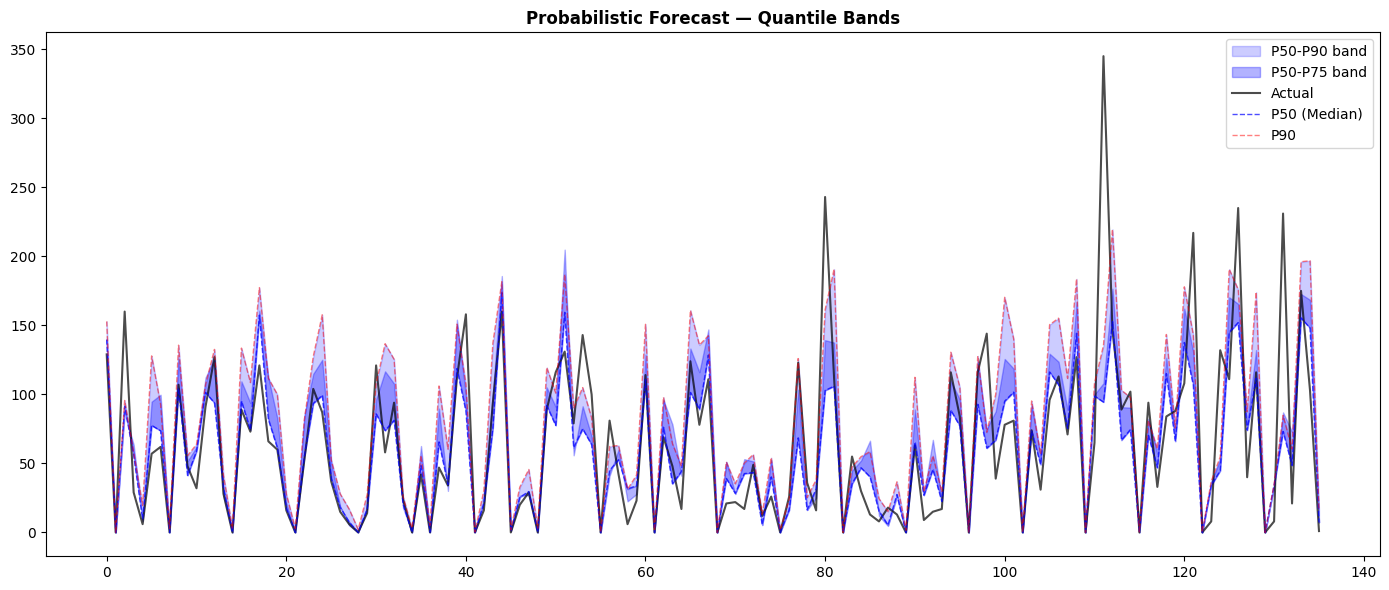

In [22]:
# ─── Quantile Regression Models ───
quantiles = {'P50': 0.50, 'P75': 0.75, 'P90': 0.90}
qr_models = {}
qr_preds = {}

for name, alpha in quantiles.items():
    qr = lgb.LGBMRegressor(
        objective='quantile', alpha=alpha,
        n_estimators=400, max_depth=6, learning_rate=0.03,
        num_leaves=31, min_child_samples=10,
        colsample_bytree=0.7, subsample=0.8,
        random_state=42, verbosity=-1
    )
    qr.fit(X_train, y_train)
    pred = np.maximum(np.expm1(qr.predict(X_test)), 0)
    qr_models[name] = qr
    qr_preds[name] = pred

    # Coverage check (kalibrasyon)
    coverage = np.mean(y_actual <= pred) * 100
    print(f"  {name} (τ={alpha:.2f}): Coverage = {coverage:.1f}% (target: {alpha*100:.0f}%)")

# Visualization
fig, ax = plt.subplots(figsize=(14, 6))
x = range(len(y_actual))
ax.fill_between(x, qr_preds['P50'], qr_preds['P90'], alpha=0.2, color='blue', label='P50-P90 band')
ax.fill_between(x, qr_preds['P50'], qr_preds['P75'], alpha=0.3, color='blue', label='P50-P75 band')
ax.plot(y_actual, 'k-', linewidth=1.5, alpha=0.7, label='Actual')
ax.plot(qr_preds['P50'], 'b--', linewidth=1, alpha=0.7, label='P50 (Median)')
ax.plot(qr_preds['P90'], 'r--', linewidth=1, alpha=0.5, label='P90')
ax.set_title('Probabilistic Forecast — Quantile Bands', fontweight='bold')
ax.legend(); plt.tight_layout(); save_fig('fig06_quantile_bands')
plt.show()

In [23]:
# ─── Calibration Analysis: Pinball Loss + Kupiec POF Test ───
from scipy import stats

n_test = len(y_actual)
print(f"Calibration analysis over {n_test}-day test window")
print(f"{'Quantile':<8} {'Nominal':>8} {'Empirical':>10} {'Violations':>11} {'Kupiec LR':>10} {'p-value':>9} {'Pinball':>9}")
print("─" * 70)

for name, alpha in quantiles.items():
    pred = qr_preds[name]
    # Empirical coverage: P(actual <= pred)
    coverage = np.mean(y_actual <= pred)
    # Violations: actual > pred (beklenen oran 1 - tau)
    x_viol = int(np.sum(y_actual > pred))
    p_exp = 1 - alpha
    pi_hat = x_viol / n_test
    # Kupiec unconditional coverage (POF) LR testi
    eps = 1e-12
    ll0 = (n_test - x_viol) * np.log(1 - p_exp + eps) + x_viol * np.log(p_exp + eps)
    ll1 = (n_test - x_viol) * np.log(1 - pi_hat + eps) + x_viol * np.log(pi_hat + eps)
    LR_uc = -2 * (ll0 - ll1)
    p_value = 1 - stats.chi2.cdf(LR_uc, df=1)
    # Pinball (quantile) loss — orijinal birim ölçeğinde
    diff = y_actual - pred
    pinball = np.mean(np.maximum(alpha * diff, (alpha - 1) * diff))
    print(f"{name:<8} {alpha*100:>7.0f}% {coverage*100:>9.1f}% {x_viol:>7d}/{n_test} {LR_uc:>10.2f} {p_value:>9.4f} {pinball:>9.2f}")

print()
print("Yorum: p < 0.05 → nominal kapsama reddedilir (kalibrasyon sapması anlamlı).")
print("P50 over-coverage = yukarı yönlü bias (medyan tahmin gerçek medyanın üzerinde).")

Calibration analysis over 136-day test window
Quantile  Nominal  Empirical  Violations  Kupiec LR   p-value   Pinball
──────────────────────────────────────────────────────────────────────
P50           50%      67.6%      44/136      17.31    0.0000     10.24
P75           75%      76.5%      32/136       0.16    0.6901     10.78
P90           90%      84.6%      21/136       3.90    0.0482      8.84

Yorum: p < 0.05 → nominal kapsama reddedilir (kalibrasyon sapması anlamlı).
P50 over-coverage = yukarı yönlü bias (medyan tahmin gerçek medyanın üzerinde).


### 8.1. 7 Seviyeli Kalibrasyon Değerlendirmesi
Hocanın `quantile_calibration.py` modülü ile: coverage, pinball, skill score, Kupiec p ve reliability diagram (yeni **Figure 7**). Aşağıdaki hücre modülü diske yazar; sonraki hücre analizi çalıştırır.

In [24]:
%%writefile quantile_calibration.py
"""
Kuantil Tahmin Kalibrasyon Değerlendirme Modülü
===============================================
Amaç: Kuantil regresyon tahminlerinin kalibrasyonunu, envanter maliyet
metriklerinden (CSL) BAĞIMSIZ olarak değerlendirmek.

Kritik metodolojik not:
-----------------------
Sipariş miktarı q(t) doğrudan kuantil tahmini olarak alındığında,
Cycle Service Level (CSL) ile ampirik kapsama (empirical coverage)
MATEMATIKSEL OLARAK ÖZDEŞTİR:

    CSL   = (1/T) * Σ 1[q(t) >= d(t)]
    Cover = (1/T) * Σ 1[d(t) <= q̂_τ(t)]

Bu nedenle CSL'i "kalibrasyon kanıtı" olarak sunmak döngüsel bir argümandır.
Bu modül, kalibrasyonu bağımsız olarak ölçen üç araç sunar:

    1. Pinball (quantile) loss   -> kuantil tahmininin PROPER SCORING RULE'u
    2. Reliability diagram        -> ince taneli kalibrasyon eğrisi
    3. Kupiec POF testi           -> kapsama sapmasının İSTATİSTİKSEL anlamlılığı

Yazar: (öğrenci adı)
Kullanım: quantile_calibration_report(y_true, q_preds, taus)
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2


# ============================================================
# 1. PINBALL (KUANTIL) KAYBI
# ============================================================

def pinball_loss(y_true, y_pred, tau):
    """
    Tek bir kuantil seviyesi için pinball (quantile) kaybı.

    L_tau(y, q) = tau * max(y - q, 0) + (1 - tau) * max(q - y, 0)

    Pinball loss, kuantil tahmini için 'proper scoring rule'dur:
    beklenen kaybı minimize eden tahmin, gerçek koşullu tau-kuantilidir.
    Bu yüzden kalibrasyonun tek başına kapsama oranından daha güvenilir
    bir göstergesidir (kapsama, keskinlikten -sharpness- bağımsızdır).

    Parametreler
    ------------
    y_true : array-like, gerçek değerler
    y_pred : array-like, tau seviyesindeki kuantil tahminleri
    tau    : float, kuantil seviyesi (0 < tau < 1)

    Dönüş
    -----
    float : ortalama pinball kaybı (düşük = iyi)
    """
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    diff = y_true - y_pred
    # tau * pozitif_hata + (1-tau) * negatif_hata
    loss = np.maximum(tau * diff, (tau - 1.0) * diff)
    return float(np.mean(loss))


def pinball_loss_baseline(y_true, tau):
    """
    Referans (naif) pinball kaybı: koşulsuz ampirik kuantil kullanan sabit tahmin.
    Modelin skill skorunu hesaplamak için gereklidir; ham pinball değeri
    tek başına yorumlanamaz (ölçek bağımlıdır).
    """
    y_true = np.asarray(y_true, dtype=float)
    const_q = np.quantile(y_true, tau)
    return pinball_loss(y_true, np.full_like(y_true, const_q), tau)


def pinball_skill_score(y_true, y_pred, tau):
    """
    Skill Score = 1 - (L_model / L_baseline)

    > 0  : model, koşulsuz ampirik kuantilden İYİ
    = 0  : modelin sabit kuantil tahmininden farkı yok
    < 0  : model, naif referanstan KÖTÜ (ciddi problem)

    Bu, hakemin "0.42 pinball iyi mi kötü mü?" sorusuna cevap verir.
    """
    l_model = pinball_loss(y_true, y_pred, tau)
    l_base = pinball_loss_baseline(y_true, tau)
    if l_base == 0:
        return np.nan
    return 1.0 - (l_model / l_base)


# ============================================================
# 2. AMPİRİK KAPSAMA VE KUPIEC TESTİ
# ============================================================

def empirical_coverage(y_true, y_pred):
    """Gerçek değerlerin tahmin edilen kuantilin ALTINDA kalma oranı."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.mean(y_true <= y_pred))


def kupiec_pof_test(y_true, y_pred, tau):
    """
    Kupiec (1995) Proportion of Failures (POF) — likelihood ratio testi.

    H0: gerçek kapsama = nominal tau (model kalibre)
    H1: gerçek kapsama != tau (model miskalibre)

    LR_POF = -2 * ln[ (1-tau)^(T-x) * tau^x / (1-p̂)^(T-x) * p̂^x ]
             ~ chi2(1) altında H0

    Bu test kritik: 67.6% vs 50% sapmasının ÖRNEKLEM GÜRÜLTÜSÜ mü yoksa
    GERÇEK MİSKALİBRASYON mu olduğunu ayırt eder. Hakem bunu sorar.

    Dönüş
    -----
    dict: LR istatistiği, p-değeri, karar
    """
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    T = len(y_true)
    x = int(np.sum(y_true <= y_pred))   # kapsanan gözlem sayısı
    p_hat = x / T                        # ampirik kapsama

    # Dejenere durumlar (log(0) koruması)
    if x == 0 or x == T:
        return {"T": T, "x": x, "p_hat": p_hat,
                "LR_stat": np.inf, "p_value": 0.0, "calibrated": False}

    # Log-likelihood: H0 (nominal tau) vs H1 (ampirik p_hat)
    ll_null = (T - x) * np.log(1 - tau) + x * np.log(tau)
    ll_alt = (T - x) * np.log(1 - p_hat) + x * np.log(p_hat)
    lr_stat = -2.0 * (ll_null - ll_alt)
    p_value = 1.0 - chi2.cdf(lr_stat, df=1)

    return {
        "T": T,
        "x": x,
        "p_hat": p_hat,
        "LR_stat": float(lr_stat),
        "p_value": float(p_value),
        "calibrated": bool(p_value > 0.05),  # %5 anlamlılık
    }


# ============================================================
# 3. RELIABILITY DIAGRAM
# ============================================================

def reliability_curve(y_true, quantile_predictor, taus=None):
    """
    İnce taneli reliability (kalibrasyon) eğrisi.

    Sadece 3 nokta (P50/P75/P90) yerine 9-19 kuantil seviyesinde
    nominal-vs-ampirik kapsamayı ölçer. Bu, kalibrasyon bozukluğunun
    SİSTEMATİK bir örüntü mü (ör. tüm dağılım kaymış) yoksa yalnızca
    kuyruklarda mı olduğunu gösterir — makaledeki 3-satırlık tablo
    bu ayrımı yapamaz.

    Parametreler
    ------------
    y_true : array-like
    quantile_predictor : callable
        tau -> tau seviyesindeki tahmin dizisi döndüren fonksiyon.
        Örn: lambda tau: models[tau].predict(X_test)
    taus : list, değerlendirilecek kuantil seviyeleri

    Dönüş
    -----
    pd.DataFrame : nominal, empirical, deviation, pinball, skill, kupiec_p
    """
    if taus is None:
        taus = [0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95]

    rows = []
    for tau in taus:
        y_pred = np.asarray(quantile_predictor(tau), dtype=float)
        cov = empirical_coverage(y_true, y_pred)
        pl = pinball_loss(y_true, y_pred, tau)
        skill = pinball_skill_score(y_true, y_pred, tau)
        kup = kupiec_pof_test(y_true, y_pred, tau)

        rows.append({
            "tau": tau,
            "nominal_%": tau * 100,
            "empirical_%": cov * 100,
            "deviation_pp": (cov - tau) * 100,
            "pinball_loss": pl,
            "skill_score": skill,
            "kupiec_p": kup["p_value"],
            "calibrated_5%": kup["calibrated"],
        })

    return pd.DataFrame(rows)


def plot_reliability_diagram(rel_df, save_path="reliability_diagram.png"):
    """
    İki panelli kalibrasyon grafiği:
      (a) Reliability diagram: nominal vs ampirik kapsama + 45° referans
      (b) Pinball skill score: kuantil seviyesine göre model becerisi
    """
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # --- Panel (a): Reliability diagram ---
    ax = axes[0]
    nominal = rel_df["nominal_%"].values
    empirical = rel_df["empirical_%"].values

    # Mükemmel kalibrasyon referans çizgisi
    ax.plot([0, 100], [0, 100], "k--", lw=1.2, label="Perfect calibration", zorder=1)

    # Model eğrisi; kalibre olmayan noktaları kırmızı işaretle
    ax.plot(nominal, empirical, "o-", color="#2166ac", lw=2,
            markersize=7, label="Model", zorder=3)

    mis = rel_df[~rel_df["calibrated_5%"]]
    if len(mis) > 0:
        ax.scatter(mis["nominal_%"], mis["empirical_%"],
                   s=140, facecolors="none", edgecolors="#b2182b",
                   lw=2.2, zorder=4, label="Miskalibre (Kupiec p<0.05)")

    ax.set_xlabel("Nominal coverage (%)")
    ax.set_ylabel("Empirical coverage (%)")
    ax.set_title("(a) Reliability Diagram")
    ax.set_xlim(0, 100); ax.set_ylim(0, 100)
    ax.grid(alpha=0.3); ax.legend(loc="upper left", fontsize=9)

    # --- Panel (b): Skill score ---
    ax = axes[1]
    colors = ["#2166ac" if s > 0 else "#b2182b" for s in rel_df["skill_score"]]
    ax.bar(rel_df["nominal_%"], rel_df["skill_score"],
           width=6, color=colors, edgecolor="black", lw=0.6)
    ax.axhline(0, color="black", lw=1.2)
    ax.set_xlabel("Quantile level (%)")
    ax.set_ylabel("Pinball Skill Score")
    ax.set_title("(b) Skill Based on Unconditional Reference")
    ax.grid(alpha=0.3, axis="y")

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    print(f"[+] Reliability diagram kaydedildi: {save_path}")
    return fig


# ============================================================
# 4. TAM RAPOR (makaleye giren tablo)
# ============================================================

def quantile_calibration_report(y_true, q_preds, taus,
                                save_fig="reliability_diagram.png",
                                verbose=True):
    """
    Makaleye girecek kalibrasyon tablosunu üretir.

    Parametreler
    ------------
    y_true  : array-like, test seti gerçek talep
    q_preds : dict {tau: tahmin_dizisi} — tüm kuantil seviyeleri
    taus    : list, raporlanacak kuantil seviyeleri

    Dönüş
    -----
    pd.DataFrame : LaTeX'e dönüştürülmeye hazır kalibrasyon tablosu
    """
    predictor = lambda t: q_preds[t]
    rel_df = reliability_curve(y_true, predictor, taus=taus)

    plot_reliability_diagram(rel_df, save_path=save_fig)

    if verbose:
        print("\n" + "=" * 78)
        print("KUANTIL KALİBRASYON RAPORU")
        print("=" * 78)
        print(f"Test seti büyüklüğü: T = {len(y_true)}")
        print("-" * 78)
        disp = rel_df.copy()
        for c in ["nominal_%", "empirical_%", "deviation_pp"]:
            disp[c] = disp[c].round(1)
        disp["pinball_loss"] = disp["pinball_loss"].round(3)
        disp["skill_score"] = disp["skill_score"].round(3)
        disp["kupiec_p"] = disp["kupiec_p"].round(4)
        print(disp.to_string(index=False))
        print("-" * 78)

        n_mis = (~rel_df["calibrated_5%"]).sum()
        print(f"Miskalibre kuantil sayısı (Kupiec p<0.05): {n_mis}/{len(rel_df)}")

        neg = rel_df[rel_df["skill_score"] <= 0]
        if len(neg) > 0:
            print(f"UYARI: {len(neg)} kuantilde skill <= 0 "
                  f"(model naif referanstan iyi değil): "
                  f"{list((neg['nominal_%']).astype(int))}")
        else:
            print("Tüm kuantillerde skill > 0 (model naif referanstan iyi).")
        print("=" * 78 + "\n")

    return rel_df


def to_latex_table(rel_df, caption="Quantile calibration assessment.",
                   label="tab:calibration"):
    """Makaleye doğrudan yapıştırılabilir LaTeX tablosu üretir."""
    lines = [
        r"\begin{table}[htbp]", r"\centering",
        rf"\caption{{{caption}}}", rf"\label{{{label}}}",
        r"\begin{tabular}{lrrrrrr}", r"\hline",
        r"Quantile & Nominal & Empirical & Dev. & Pinball & Skill & Kupiec \\",
        r" & (\%) & (\%) & (pp) & Loss & Score & $p$ \\", r"\hline",
    ]
    for _, r in rel_df.iterrows():
        star = r"$^{*}$" if r["kupiec_p"] < 0.05 else ""
        lines.append(
            f"P{int(r['nominal_%'])} & {r['nominal_%']:.1f} & "
            f"{r['empirical_%']:.1f} & {r['deviation_pp']:+.1f} & "
            f"{r['pinball_loss']:.3f} & {r['skill_score']:.3f} & "
            f"{r['kupiec_p']:.3f}{star} \\\\"
        )
    lines += [
        r"\hline", r"\end{tabular}",
        r"\begin{tablenotes}\footnotesize",
        r"\item $^{*}$ Rejects calibration at the 5\% level (Kupiec POF test).",
        r"\item Skill Score $= 1 - L_{\text{model}}/L_{\text{baseline}}$; "
        r"baseline is the unconditional empirical quantile.",
        r"\end{tablenotes}", r"\end{table}",
    ]
    return "\n".join(lines)


# ============================================================
# 5. ENTEGRASYON ÖRNEĞİ
# ============================================================

if __name__ == "__main__":
    """
    KENDİ PIPELINE'INA ENTEGRASYON:
    -------------------------------
    Mevcut kodunda zaten 3 kuantil modeli (P50/P75/P90) var. Kalibrasyonu
    doğru ölçmek için DAHA FAZLA kuantil seviyesinde model eğitmen gerekiyor,
    çünkü 3 nokta bir reliability diagram için yetersiz.

        import lightgbm as lgb
        from quantile_calibration import quantile_calibration_report, to_latex_table

        TAUS = [0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95]
        q_models, q_preds = {}, {}

        for tau in TAUS:
            m = lgb.LGBMRegressor(
                objective="quantile", alpha=tau,
                n_estimators=400, max_depth=6, learning_rate=0.03,
                num_leaves=31, colsample_bytree=0.7, random_state=42,
            )
            m.fit(X_train, y_train)
            q_models[tau] = m
            # ÖNEMLİ: log-dönüşümü geri al (makalede log(1+y) kullanılıyor)
            q_preds[tau] = np.expm1(m.predict(X_test))

        y_test_orig = np.expm1(y_test)   # gerçek ölçeğe dön

        rel_df = quantile_calibration_report(y_test_orig, q_preds, TAUS)
        print(to_latex_table(rel_df))

    Aşağıdaki blok, modülün doğru çalıştığını SENTETİK veriyle doğrular.
    Bu sayılar makaleye GİRMEZ — sadece kodun testidir.
    """
    rng = np.random.default_rng(42)
    T = 300

    # Sentetik sıfır-şişkin talep (makaledeki veriye benzer yapı)
    zero_mask = rng.random(T) < 0.35
    y = np.where(zero_mask, 0.0, rng.gamma(shape=3.0, scale=25.0, size=T))

    TAUS = [0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95]

    # Kasıtlı olarak MİSKALİBRE tahminler üret (medyanı yukarı kaydır),
    # böylece testlerin bunu yakalayıp yakalamadığını görürüz.
    q_preds = {}
    for tau in TAUS:
        true_q = np.quantile(y, tau)
        bias = 12.0 if tau <= 0.5 else -6.0   # P50 yukarı, üst kuyruk aşağı
        q_preds[tau] = np.full(T, true_q + bias)

    rel_df = quantile_calibration_report(
        y, q_preds, TAUS, save_fig="/home/claude/reliability_test.png"
    )

    print("\n--- LaTeX ÇIKTISI ---")
    print(to_latex_table(rel_df))


Writing quantile_calibration.py


[+] Reliability diagram kaydedildi: figures_300dpi/fig07_reliability_diagram.png

KUANTIL KALİBRASYON RAPORU
Test seti büyüklüğü: T = 136
------------------------------------------------------------------------------
 tau  nominal_%  empirical_%  deviation_pp  pinball_loss  skill_score  kupiec_p  calibrated_5%
0.05        5.0         33.1          28.1         2.069        0.350    0.0000          False
0.10       10.0         36.8          26.8         3.043        0.522    0.0000          False
0.25       25.0         58.8          33.8         6.667        0.560    0.0000          False
0.50       50.0         67.6          17.6        10.245        0.574    0.0000          False
0.75       75.0         76.5           1.5        10.783        0.473    0.6901           True
0.90       90.0         84.6          -5.4         8.837        0.294    0.0482          False
0.95       95.0         86.8          -8.2         7.786        0.072    0.0002          False
-----------------------

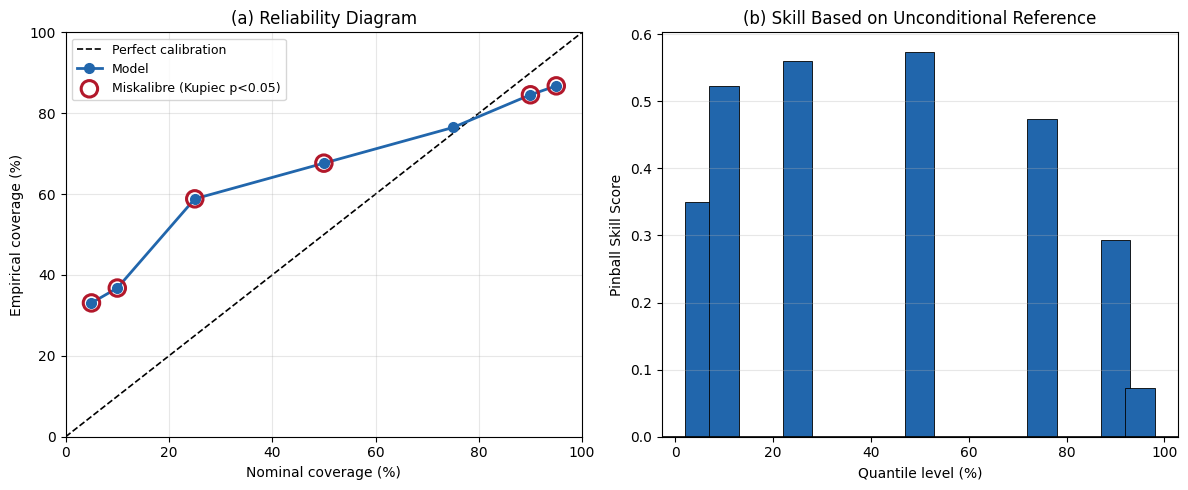

In [25]:
# ─── 7 Seviyeli Kuantil Kalibrasyon (Hoca revizesi: yeni Tablo 8 + yeni Figure 7) ───
# TUTARLILIK: P50/P75/P90 tahminleri YENİDEN EĞİTİLMEZ, mevcut qr_preds'ten
# alınır → makaledeki Tablo 8 ile özdeşlik garanti. Yalnızca P5/P10/P25/P95
# yeni eğitilir; hiperparametreler yukarıdaki kuantil hücresiyle birebir aynı
# (min_child_samples=10 ve subsample=0.8 dahil) ve negatif kırpma korunur.
from quantile_calibration import quantile_calibration_report, to_latex_table

TAUS = [0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95]
EXISTING = {0.50: 'P50', 0.75: 'P75', 0.90: 'P90'}

q_preds_full = {}
for tau in TAUS:
    if tau in EXISTING:
        q_preds_full[tau] = qr_preds[EXISTING[tau]]
        continue
    _m = lgb.LGBMRegressor(
        objective='quantile', alpha=tau,
        n_estimators=400, max_depth=6, learning_rate=0.03,
        num_leaves=31, min_child_samples=10,
        colsample_bytree=0.7, subsample=0.8,
        random_state=42, verbosity=-1,
    )
    _m.fit(X_train, y_train)
    q_preds_full[tau] = np.maximum(np.expm1(_m.predict(X_test)), 0)

rel_df = quantile_calibration_report(
    y_actual, q_preds_full, TAUS,
    save_fig=os.path.join(FIGDIR, 'fig07_reliability_diagram.png'),
)

print(to_latex_table(
    rel_df,
    caption=('Quantile calibration on the test set ($n=136$ days): empirical '
             'coverage, pinball loss, skill score, and Kupiec POF test across '
             'seven quantile levels.'),
    label='tab:calibration',
))

# Sağlama: P50/P75/P90 satırları makaledeki mevcut Tablo 8 ile aynı olmalı.
for tau, exp_cov in [(0.50, 67.6), (0.75, 76.5), (0.90, 84.6)]:
    got = rel_df.loc[rel_df['tau'] == tau, 'empirical_%'].iloc[0]
    flag = 'OK ✅' if abs(got - exp_cov) < 0.05 else '❌ TABLO 8 İLE UYUŞMUYOR — hocaya göndermeden önce kontrol et!'
    print(f"  Sağlama P{int(tau*100)}: empirical={got:.1f}% (beklenen {exp_cov}%) {flag}")


## 9. 🔍 SHAP Explainability (Açıklanabilir Yapay Zeka)

**Referans:** Cooper et al. (2025) — LightGBM + SHAP  
**Amaç:** Hangi özelliklerin talep tahminini nasıl etkilediğini SHAP ile açıklamak.

Computing SHAP values (LightGBM)...

📊 SHAP Feature Importance (Top 10):
  num_transactions          0.8313 ████████████████
  unit_price                0.3607 ███████
  num_customers             0.2874 █████
  sin_dow                   0.0747 █
  price_change              0.0484 
  sales_lag_28              0.0189 
  rolling_std_7             0.0155 
  sales_lag_7               0.0132 
  rolling_mean_7            0.0114 
  sales_lag_14              0.0113 
  [kaydedildi] figures_300dpi/fig08_shap_beeswarm.png


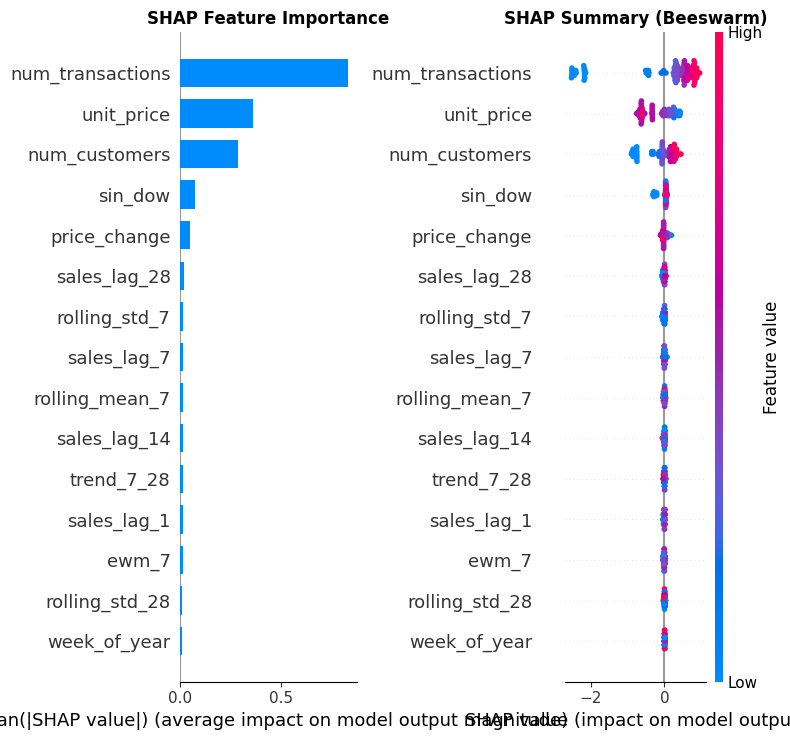

In [28]:
# ─── SHAP Analysis ───
print("Computing SHAP values (LightGBM)...")
explainer = shap.TreeExplainer(lgb_model)
shap_values = explainer.shap_values(X_test[:300])

# Feature importance
imp = dict(zip(FEATURE_COLS, np.abs(shap_values).mean(axis=0)))
sf = sorted(imp.items(), key=lambda x: x[1], reverse=True)
print("\n📊 SHAP Feature Importance (Top 10):")
for f, v in sf[:10]:
    bar = '█' * int(v * 20)
    print(f"  {f:<25} {v:.4f} {bar}")

# SHAP plots
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
plt.sca(axes[0])
shap.summary_plot(shap_values, X_test[:300], feature_names=FEATURE_COLS, plot_type='bar', max_display=15, show=False)
axes[0].set_title('SHAP Feature Importance', fontweight='bold')

plt.sca(axes[1])
shap.summary_plot(shap_values, X_test[:300], feature_names=FEATURE_COLS, max_display=15, show=False)
axes[1].set_title('SHAP Summary (Beeswarm)', fontweight='bold')

plt.tight_layout(); save_fig('fig08_shap_beeswarm')
plt.show()

## 10. 📦 Newsvendor Inventory Optimization

**Referans:** Ngartera et al. (2026) — Critical Fractile + CVaR₉₅  
**Formül:** Optimal sipariş miktarı: $q^* = F_D^{-1}\left(\frac{s}{s+h}\right)$  
**Burada:**
- $s$ = Stokta kalmama maliyeti (stockout cost)
- $h$ = Elde tutma maliyeti (holding cost)
- $s/h = 5$ → $\tau^* = 5/6 ≈ 0.833$ → P75-P90 arası optimal

📦 Newsvendor Parameters:
   Holding cost (h): £0.5/unit
   Stockout cost (s): £2.5/unit
   Cost ratio (s/h): 5.0
   Critical fractile (τ*): 0.833

Policy                     Mean Cost     CSL%  Stockouts Overstocks
─────────────────────────────────────────────────────────────────
  P50 (Risk-Neutral)        £   35.62    67.6%      1725      1061
  P75 (Moderate)            £   30.80    76.5%      1256      2098
  P90 (Risk-Averse)         £   29.65    84.6%       989      3122
  LightGBM (Point)          £   33.97    70.6%      1621      1136
  [kaydedildi] figures_300dpi/fig09_newsvendor.png


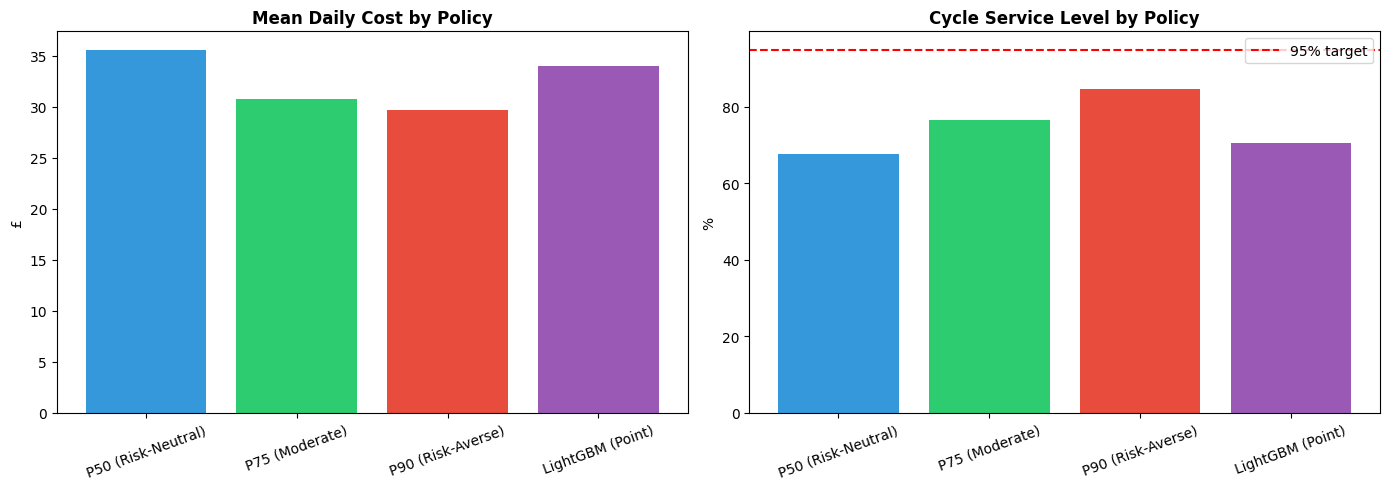

In [29]:
# ─── Newsvendor Inventory Optimization ───
# Maliyet parametreleri
h_cost = 0.50   # holding cost (elde tutma)
s_cost = 2.50   # stockout cost (stokta kalmama) — s/h = 5
critical_fractile = s_cost / (s_cost + h_cost)  # τ* = 0.833

print(f"📦 Newsvendor Parameters:")
print(f"   Holding cost (h): £{h_cost}/unit")
print(f"   Stockout cost (s): £{s_cost}/unit")
print(f"   Cost ratio (s/h): {s_cost/h_cost:.1f}")
print(f"   Critical fractile (τ*): {critical_fractile:.3f}")

# Farklı politikaları karşılaştır
policies = {
    'P50 (Risk-Neutral)': qr_preds['P50'],
    'P75 (Moderate)': qr_preds['P75'],
    'P90 (Risk-Averse)': qr_preds['P90'],
    'LightGBM (Point)': y_pred_lgb
}

print(f"\n{'Policy':<25} {'Mean Cost':>10} {'CSL%':>8} {'Stockouts':>10} {'Overstocks':>10}")
print("─" * 65)

inv_results = {}
for name, q_pred in policies.items():
    order_qty = np.maximum(q_pred, 0)
    overstock = np.maximum(order_qty - y_actual, 0)
    stockout = np.maximum(y_actual - order_qty, 0)
    total_cost = h_cost * overstock.sum() + s_cost * stockout.sum()
    mean_cost = total_cost / len(y_actual)
    csl = np.mean(y_actual <= order_qty) * 100
    inv_results[name] = {'mean_cost': mean_cost, 'csl': csl,
                         'stockouts': stockout.sum(), 'overstocks': overstock.sum()}
    print(f"  {name:<25} £{mean_cost:>8.2f} {csl:>7.1f}% {stockout.sum():>9.0f} {overstock.sum():>9.0f}")

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
names = list(inv_results.keys())
costs = [inv_results[n]['mean_cost'] for n in names]
csls = [inv_results[n]['csl'] for n in names]

ax1.bar(names, costs, color=['#3498db', '#2ecc71', '#e74c3c', '#9b59b6'])
ax1.set_title('Mean Daily Cost by Policy', fontweight='bold')
ax1.set_ylabel('£'); ax1.tick_params(axis='x', rotation=20)

ax2.bar(names, csls, color=['#3498db', '#2ecc71', '#e74c3c', '#9b59b6'])
ax2.set_title('Cycle Service Level by Policy', fontweight='bold')
ax2.set_ylabel('%'); ax2.axhline(y=95, color='red', linestyle='--', label='95% target')
ax2.tick_params(axis='x', rotation=20); ax2.legend()

plt.tight_layout(); save_fig('fig09_newsvendor')
plt.show()

### 10.1. Maliyet Oranı Duyarlılık Analizi
`cs/ch ∈ {2, 3, 5, 10}` için politika maliyetleri — P90 optimalliğinin sınırı.

In [30]:
# ─── Maliyet Oranı Duyarlılık Analizi (cs/ch = 2, 3, 5, 10) ───
# Amaç: P90'ın hangi oranda maliyet-optimal olmaktan çıktığını göstermek.
# h sabit (£0.50), s = oran × h. Limitations'taki vaat bununla kapanıyor.
RATIOS = [2, 3, 5, 10]
_POL = {'P50': qr_preds['P50'], 'P75': qr_preds['P75'], 'P90': qr_preds['P90']}
_h = 0.50
_n = len(y_actual)

_rows = []
for _ratio in RATIOS:
    _s = _ratio * _h
    _tau_star = _s / (_s + _h)
    _costs = {}
    for _p, _q in _POL.items():
        _over = np.maximum(_q - y_actual, 0).sum()
        _short = np.maximum(y_actual - _q, 0).sum()
        _costs[_p] = (_h * _over + _s * _short) / _n
    _best = min(_costs, key=_costs.get)
    _rows.append({'ratio': _ratio, 'tau_star': _tau_star, **_costs, 'best': _best})

sens_df = pd.DataFrame(_rows)
print("COST-RATIO SENSITIVITY (mean daily cost, £)")
print(f"{'cs/ch':>6} {'tau*':>7} {'P50':>9} {'P75':>9} {'P90':>9}   Optimal")
print('─' * 55)
for _, r in sens_df.iterrows():
    print(f"{r['ratio']:>6.0f} {r['tau_star']:>7.3f} "
          f"{r['P50']:>9.2f} {r['P75']:>9.2f} {r['P90']:>9.2f}   {r['best']}")

print("\n% --- LaTeX: makaleye yapıştırılacak duyarlılık tablosu ---")
print(r"\begin{table}[H]")
print(r"\centering")
print(r"\caption{Cost-ratio sensitivity of Newsvendor policies: mean daily cost "
      r"(\pounds) over the 136-day test window ($c_h=\pounds0.50$). Bold marks "
      r"the cost-optimal policy at each ratio.}")
print(r"\label{tab:sensitivity}")
print(r"\begin{tabular}{rrrrr}")
print(r"\hline")
print(r"$c_s/c_h$ & $\tau^{*}$ & P50 & P75 & P90 \\")
print(r"\hline")
for _, r in sens_df.iterrows():
    _cells = []
    for _p in ['P50', 'P75', 'P90']:
        _v = f"{r[_p]:.2f}"
        _cells.append(rf"\textbf{{{_v}}}" if _p == r['best'] else _v)
    print(f"{r['ratio']:.0f} & {r['tau_star']:.3f} & " + " & ".join(_cells) + r" \\")
print(r"\hline")
print(r"\end{tabular}")
print(r"\end{table}")


COST-RATIO SENSITIVITY (mean daily cost, £)
 cs/ch    tau*       P50       P75       P90   Optimal
───────────────────────────────────────────────────────
     2   0.667     16.59     16.95     18.75   P50
     3   0.750     22.93     21.57     22.38   P75
     5   0.833     35.62     30.80     29.65   P90
    10   0.909     67.33     53.89     47.82   P90

% --- LaTeX: makaleye yapıştırılacak duyarlılık tablosu ---
\begin{table}[H]
\centering
\caption{Cost-ratio sensitivity of Newsvendor policies: mean daily cost (\pounds) over the 136-day test window ($c_h=\pounds0.50$). Bold marks the cost-optimal policy at each ratio.}
\label{tab:sensitivity}
\begin{tabular}{rrrrr}
\hline
$c_s/c_h$ & $\tau^{*}$ & P50 & P75 & P90 \\
\hline
2 & 0.667 & \textbf{16.59} & 16.95 & 18.75 \\
3 & 0.750 & 22.93 & \textbf{21.57} & 22.38 \\
5 & 0.833 & 35.62 & 30.80 & \textbf{29.65} \\
10 & 0.909 & 67.33 & 53.89 & \textbf{47.82} \\
\hline
\end{tabular}
\end{table}


In [31]:
# Not: Fig 1 (mimari) harici görsel, Fig 10-14 (chatbot) ekran görüntüsü —
# bunlar bu klasörde ÜRETİLMEZ, ayrıca eklenecek.
!zip -r -q figures_300dpi.zip figures_300dpi
!ls -la figures_300dpi/
print("\n✅ figures_300dpi.zip hazır — sol panelden indirilebilir.")


total 3988
drwxr-xr-x 2 root root    4096 Jul 18 19:24 .
drwxr-xr-x 1 root root    4096 Jul 18 19:24 ..
-rw-r--r-- 1 root root  670817 Jul 18 19:18 fig02_eda_dashboard.png
-rw-r--r-- 1 root root  504828 Jul 18 19:18 fig03_correlation.png
-rw-r--r-- 1 root root  389265 Jul 18 19:20 fig04_model_comparison.png
-rw-r--r-- 1 root root  755128 Jul 18 19:20 fig05_actual_vs_pred.png
-rw-r--r-- 1 root root 1056089 Jul 18 19:21 fig06_quantile_bands.png
-rw-r--r-- 1 root root  229950 Jul 18 19:22 fig07_reliability_diagram.png
-rw-r--r-- 1 root root  283295 Jul 18 19:24 fig08_shap_beeswarm.png
-rw-r--r-- 1 root root  165941 Jul 18 19:24 fig09_newsvendor.png

✅ figures_300dpi.zip hazır — sol panelden indirilebilir.


## 11. Gradio Chatbot Interface 🤖

In [32]:
import re
best_model_name = comparison_df.index[0]
best_r2 = comparison_df.iloc[0]['R2']

def chatbot_response(message, history):
    msg = message.lower().strip()
    try:
        if any(w in msg for w in ['hello','hi','hey','help','merhaba']):
            return (f'Hello! 👋 Model: **{best_model_name}** (R²={best_r2:.4f})\n\n'
                f'📊 "sales report" — Sales data\n'
                f'🔮 "forecast 7 days" — Demand forecast\n'
                f'📦 "inventory" — Stock optimization\n'
                f'🏆 "top products" — Best sellers\n'
                f'🤖 "model performance" — All models\n'
                f'🔍 "explain" — SHAP drivers\n'
                f'📈 "quantile" — Probabilistic forecast')

        elif any(w in msg for w in ['quantile','probabilistic','confidence','güven']):
            r = '📈 **Quantile Forecast (Olasılıksal Tahmin)**\n\n'
            for name, alpha in quantiles.items():
                cov = np.mean(y_actual <= qr_preds[name]) * 100
                avg = qr_preds[name].mean()
                r += f'  **{name}** (τ={alpha}): Avg={avg:.0f} units, Coverage={cov:.1f}%\n'
            r += f'\nCritical fractile τ*={critical_fractile:.3f} (s/h={s_cost/h_cost:.0f})'
            return r

        elif any(w in msg for w in ['inventory','stock','stok','newsvendor']):
            r = '📦 **Inventory Optimization (Newsvendor)**\n\n'
            r += f'Cost ratio s/h = {s_cost/h_cost:.0f} → τ* = {critical_fractile:.3f}\n\n'
            for name, res in inv_results.items():
                r += f'  **{name}**: Cost=£{res["mean_cost"]:.2f}/day, CSL={res["csl"]:.1f}%\n'
            return r

        elif any(w in msg for w in ['forecast', 'predict', 'tahmin']):
            m = re.search(r'(\d+)\s*(day|gün)', msg)
            h = int(m.group(1)) if m else 7
            h = max(1, min(h, len(y_actual)))
            dates = pd.to_datetime(demo_data['date']).iloc[-h:].dt.strftime('%Y-%m-%d').tolist()
            preds = predictions[best_model_name][-h:]
            r = f'🔮 **Demand Forecast — Next {h} Days** ({best_model_name})\n\n'
            for d, p in zip(dates, preds):
                r += f'  📅 {d}: **{p:.0f} units**\n'
            r += f'\nModel: {best_model_name} (R²={best_r2:.4f})'
            return r

        elif any(w in msg for w in ['model','performance','accuracy','r2','performans']):
            r = '🤖 **Model Performance (Densified Data)**\n\n'
            for n, row in comparison_df.iterrows():
                star = ' ⭐' if n == best_model_name else ''
                r += f"{n}: R²={row['R2']:.4f}, MAE={row['MAE']:.2f}, SMAPE={row['SMAPE']:.1f}%{star}\n"
            return r

        elif any(w in msg for w in ['why','explain','shap','factor','driver','açıkla','neden']):
            r = '🔍 **SHAP Feature Drivers (Top 10)**\n\n'
            for f, v in sf[:10]:
                r += f'  📊 **{f}**: {v:.4f}\n'
            return r

        elif any(w in msg for w in ['country', 'countries', 'compare', 'ülke', 'karşılaştır']):
            g = merged_df.groupby('Country').agg(
                total=('sales_quantity', 'sum'),
                revenue=('total_revenue', 'sum'),
                zero=('sales_quantity', lambda x: (x == 0).mean() * 100)
            ).sort_values('total', ascending=False)
            r = '🌍 **Country Comparison (Densified Data)**\n\n'
            for c, row in g.iterrows():
                r += (f'  **{c}**: {int(row["total"]):,} units, '
                      f'£{row["revenue"]:,.0f}, zero-days {row["zero"]:.1f}%\n')
            return r

        elif any(w in msg for w in ['top','best','most','popular','en çok']):
            top = merged_df.groupby('product_name')['sales_quantity'].sum().nlargest(5)
            r = '🏆 **Top 5 Products (Densified Data)**\n\n'
            for i, (n, v) in enumerate(top.items()):
                r += f'{["🥇","🥈","🥉","4️⃣","5️⃣"][i]} **{str(n)[:40]}**: {int(v):,}\n'
            return r

        elif any(w in msg for w in ['sales','report','revenue','satış','rapor']):
            days = 30
            df_f = merged_df[merged_df['date'] >= merged_df['date'].max() - timedelta(days=days)]
            return (f'📊 **Sales Report** (Last {days} days)\n\n'
                f'• Total: **{int(df_f["sales_quantity"].sum()):,} units**\n'
                f'• Revenue: **£{df_f["total_revenue"].sum():,.0f}**\n'
                f'• Daily avg: **{df_f.groupby("date")["sales_quantity"].sum().mean():.0f} units**\n'
                f'• Zero-demand days: **{(df_f["sales_quantity"]==0).mean()*100:.1f}%**')

        else:
            return 'Type "help" for available commands.'
    except Exception as e:
        return f'⚠️ Error: {e}'

print(f"✅ Chatbot ready: {best_model_name} (R²={best_r2:.4f})")

✅ Chatbot ready: Random Forest (R²=0.6269)


In [34]:
EXAMPLES = ['Hello', 'Model performance', 'Quantile forecast',
    'Inventory optimization', 'SHAP explain', 'Top products', 'Sales report']

print(f'Gradio sürümü: {gr.__version__}')

with gr.Blocks(theme=gr.themes.Soft(), title='Demand Forecasting Framework') as demo:
    gr.Markdown(f'# 📦 Explainable Multi-Horizon Demand Forecasting\n'
                f'**{best_model_name}** (R²={best_r2:.4f}) | Densified Data | Quantile + SHAP + Newsvendor')
    try:
        chatbot_ui = gr.Chatbot(height=500, type='messages')
    except TypeError:
        # Gradio 6+: type parametresi yok, messages zaten varsayılan ve tek format
        chatbot_ui = gr.Chatbot(height=500)
    msg = gr.Textbox(placeholder='Ask about sales, forecasts, inventory...', label='Message')
    with gr.Row():
        submit = gr.Button('Send 📨', variant='primary')
        clear = gr.Button('Clear 🗑️')
    gr.Examples(examples=EXAMPLES, inputs=msg)

    def respond(message, chat_history):
        chat_history = list(chat_history) if chat_history else []
        response = chatbot_response(message, chat_history)
        chat_history.append({'role': 'user', 'content': message})
        chat_history.append({'role': 'assistant', 'content': response})
        return '', chat_history

    submit.click(respond, [msg, chatbot_ui], [msg, chatbot_ui])
    msg.submit(respond, [msg, chatbot_ui], [msg, chatbot_ui])
    clear.click(lambda: ('', []), None, [msg, chatbot_ui])

demo.launch(debug=True)

Gradio sürümü: 6.20.0
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: [public-share-link-removed]

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> [public-share-link-removed]


## 12. Summary & Contributions

### Akademik Katkılar:

| # | Katkı | Referans Makale | Bu Çalışmanın Farkı |
|---|---|---|---|
| 1 | **Densification** ile doğru veri pipeline | Ngartera (2026) | Tüm SKU×Ülke çiftleri için tam panel |
| 2 | **Olasılıksal tahmin** (Quantile Regression) | Ngartera (2026) | P50, P75, P90 ile güven bandları |
| 3 | **SHAP açıklanabilirlik** | Cooper (2025) | Feature-level karar açıklaması |
| 4 | **Newsvendor stok optimizasyonu** | Ngartera (2026) | Asimetrik maliyet senaryoları |
| 5 | **Multi-model karşılaştırma** | Zhao (2025) | LSTM, GRU, RF, XGB, LGB, Ensemble |
| 6 | **Karar destek chatbot** | — (Orijinal) | Gradio ile interaktif sorgulama |

### Birleşik Framework'ün Yeniliği:
Literatürdeki çalışmalar bu bileşenleri **ayrı ayrı** ele alır. Bu çalışma, **densification → multi-model tahmin → olasılıksal çıktı → SHAP açıklama → Newsvendor optimizasyonu → chatbot arayüzü** zincirini **tek bir birleşik framework** olarak sunar.

### Metrikler:
- **Nokta tahmini**: MAE, RMSE, R², MAPE, SMAPE
- **Olasılıksal**: Quantile coverage (kalibrasyon)
- **Stok**: Cycle Service Level, Mean daily cost
- **Açıklanabilirlik**: SHAP feature importance